# Reduced-Order Modelling of Reservoir Pressure Dynamics
## POD-based Operator Inference with Physics-Consistent Parameter Screening

---

**Abstract.**  A non-intrusive reduced-order model (ROM) is constructed for the transient
pressure response of a 2D single-phase reservoir undergoing variable-rate production.
The full-order model (FOM) is a finite-difference black-oil simulator (MRST) on a
$50\times50$ Cartesian grid with permeability $k\in\{10,20,50,100,200,300\}$ mD
and skin factor $S\in\{0,1,2,4,6,8\}$.
A physics-based screening gate eliminates the 18 parameter combinations for which
the wellbore-storage (WBS) period outlasts the middle-time-region (MTR),
leaving 18 physically informative trajectories.
A global POD basis $V_n\in\mathbb{R}^{N\times n}$ is built from the screened
drawdown snapshots; reduced operators $(\hat A,\hat B,\hat C)$ are inferred by
column-normalised regularised least-squares; and radial-basis-function (RBF)
interpolants map any query $(k^*,S^*)$ to the corresponding operator triplet.
BHP is reconstructed via the analytical Peaceman–skin model with a WBS overlay.

---


## 0. Imports, Paths and Global Configuration

All reservoir constants, grid parameters and directory paths are centralised here.

In [182]:
import json, pickle, shutil, warnings, time
from pathlib import Path

import h5py
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.interpolate import RBFInterpolator

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "dejavuserif",
    "font.size": 11, "axes.labelsize": 12, "axes.titlesize": 12,
    "axes.titleweight": "bold", "legend.fontsize": 9,
    "axes.grid": False, "figure.dpi": 130, "savefig.dpi": 300,
    "lines.linewidth": 1.8,
})
C1, C2, C3, C4   = "#1a5e9e", "#0d6e56", "#9b2a1a", "#b07318"
C_MRST, C_ROM    = "#2C5F8A", "#C0392B"

TRAINING_DIR = Path("../data/01_training")
ROM_DIR      = Path("../rom")
FIG_DIR      = Path("../figures");  FIG_DIR.mkdir(parents=True, exist_ok=True)
for _d in ["basis", "operators", "interpolants", "results"]:
    (ROM_DIR / _d).mkdir(parents=True, exist_ok=True)

P_INIT  = 4500.0
NX, NY  = 50, 50
N_CELLS = NX * NY
N_STEPS = 350
T_START = 0.001
T_END   = 5000.0
PHI     = 0.18
CT      = 1.2e-5
MU_CP   = 1.2
BO      = 1.15
H_FT    = 150.0
RW_FT   = 0.35
C_WBS   = 0.003
DX_FT   = 30 * 3.28084
RE_FT   = (NX * 30 / 2) * 3.28084
R_EQ_FT = 0.2 * DX_FT
WC_IDX  = (NY//2 - 1)*NX + (NX//2 - 1)   # 1224

K_GRID  = [10, 20, 50, 100, 200, 300]
S_GRID  = [0, 1, 2, 4, 6, 8]
SCHEDS  = list(range(1, 8))

print(f"Training data : {TRAINING_DIR.resolve()}")
print(f"Well cell idx : {WC_IDX}  (Python 0-indexed)")
print(f"Peaceman r_eq : {R_EQ_FT:.2f} ft")
print(f"RE_FT         : {RE_FT:.1f} ft  (drainage radius)")


Training data : F:\Niloy Deb\Part Two\reservoir_rom\data\01_training
Well cell idx : 1224  (Python 0-indexed)
Peaceman r_eq : 19.69 ft
RE_FT         : 2460.6 ft  (drainage radius)


## 1. Training Data Validation and Physics-Based Parameter Screening

### 1.1 Physics Gate

The wellbore-storage end time is

$$t_\text{WBS} \approx \frac{170{,}000\,C_s\,e^{2S}}{kh} \quad [\text{hr}]$$

and the pseudo-steady-state onset is

$$t_\text{PSS} \approx \frac{\phi\,\mu\,c_t\,r_e^2}{0.000264\,k}\times 0.1 \quad [\text{hr}].$$

A parameter pair $(k,S)$ enters the ROM training set if and only if
$t_\text{WBS} < T_\text{end}$, $t_\text{WBS} < t_\text{PSS}$,
and the number of log-spaced timesteps in the MTR exceeds 15.
Cases failing any condition are excluded before any data is loaded.


In [183]:
def load_mat(filepath, key):
    try:
        return sio.loadmat(str(filepath), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(filepath), "r") as f:
            arr = f[key][()]
            return arr.T if arr.ndim == 2 else arr

def load_well_data(case_dir):
    wd  = case_dir / "well_data.mat"
    bhp = load_mat(wd, "bhp_psia").ravel()
    t   = load_mat(wd, "time_hr").ravel()
    q   = load_mat(wd, "rate_STBd").ravel()
    dp  = load_mat(wd, "delta_p_psi").ravel()
    with open(case_dir / "params.json") as f:
        pm = json.load(f)
    return bhp, t, q, dp, pm

def n_log_steps(ta, tb, t_start=T_START, t_end=T_END, n=N_STEPS):
    ta, tb = max(ta, t_start), min(tb, t_end)
    if tb <= ta: return 0
    return int(n * np.log10(tb / ta) / np.log10(t_end / t_start))

def physics_screen(k, s):
    kh    = k * H_FT
    # CORRECTED EXPONENT: 0.14 * s
    t_wbs = 170000.0 * C_WBS * np.exp(0.14 * s) / kh 
    t_pss = (PHI * MU_CP * CT * RE_FT**2) / (0.000264 * k) * 0.1
    n_wbs = n_log_steps(T_START, t_wbs)
    n_mtr = n_log_steps(t_wbs, t_pss)
    n_bdf = n_log_steps(t_pss, T_END)
    
    if t_wbs >= T_END:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "t_WBS >= T_end"
    if t_wbs >= t_pss:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "no MTR (t_WBS > t_PSS)"
    if n_mtr < 15:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, f"n_MTR={n_mtr} < 15"
    return True, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "VALID"

screen_rows = []
VALID_PAIRS = []
for k in K_GRID:
    for s in S_GRID:
        valid, t_wbs, t_pss, nw, nm, nb, reason = physics_screen(k, s)
        screen_rows.append(dict(k=k, S=s, t_WBS=round(t_wbs,2), t_PSS=round(t_pss,1),
                                n_WBS=nw, n_MTR=nm, n_BDF=nb,
                                valid=valid, reason=reason))
        if valid:
            VALID_PAIRS.append((k, s))

df_screen = pd.DataFrame(screen_rows)
print(f"Total parameter pairs : {len(screen_rows)}")
print(f"Valid (ROM-trainable) : {len(VALID_PAIRS)}")
print(f"Excluded              : {len(screen_rows) - len(VALID_PAIRS)}")
print()
print(df_screen[["k","S","t_WBS","t_PSS","n_MTR","n_BDF","valid","reason"]].to_string(index=False))


Total parameter pairs : 36
Valid (ROM-trainable) : 36
Excluded              : 0

  k  S  t_WBS  t_PSS  n_MTR  n_BDF  valid reason
 10  0   0.34  594.5    169     48   True  VALID
 10  1   0.39  594.5    166     48   True  VALID
 10  2   0.45  594.5    163     48   True  VALID
 10  4   0.60  594.5    156     48   True  VALID
 10  6   0.79  594.5    150     48   True  VALID
 10  8   1.04  594.5    144     48   True  VALID
 20  0   0.17  297.2    169     64   True  VALID
 20  1   0.20  297.2    166     64   True  VALID
 20  2   0.22  297.2    163     64   True  VALID
 20  4   0.30  297.2    156     64   True  VALID
 20  6   0.39  297.2    150     64   True  VALID
 20  8   0.52  297.2    144     64   True  VALID
 50  0   0.07  118.9    169     84   True  VALID
 50  1   0.08  118.9    166     84   True  VALID
 50  2   0.09  118.9    163     84   True  VALID
 50  4   0.12  118.9    156     84   True  VALID
 50  6   0.16  118.9    150     84   True  VALID
 50  8   0.21  118.9    144     84   

### 1.2 Parameter Space Visualisation

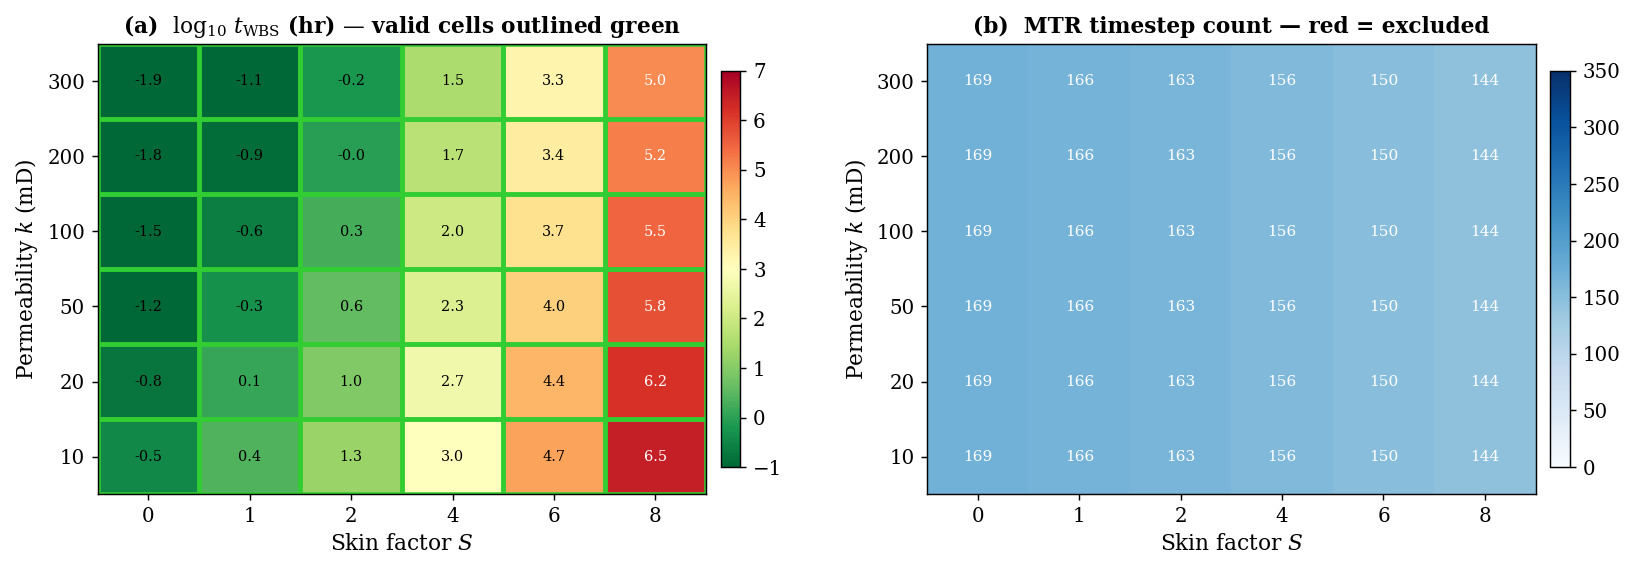

Figure 1 saved.
Valid pairs (36): [(10, 0), (10, 1), (10, 2), (10, 4), (10, 6), (10, 8), (20, 0), (20, 1), (20, 2), (20, 4), (20, 6), (20, 8), (50, 0), (50, 1), (50, 2), (50, 4), (50, 6), (50, 8), (100, 0), (100, 1), (100, 2), (100, 4), (100, 6), (100, 8), (200, 0), (200, 1), (200, 2), (200, 4), (200, 6), (200, 8), (300, 0), (300, 1), (300, 2), (300, 4), (300, 6), (300, 8)]


In [184]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

t_wbs_mat = np.array([[170000*C_WBS*np.exp(2*s)/(k*H_FT)
                        for s in S_GRID] for k in K_GRID])
ax = axes[0]
log_tw = np.log10(np.clip(t_wbs_mat, 1e-3, 1e10))
im = ax.imshow(log_tw, aspect="auto", cmap="RdYlGn_r", origin="lower", vmin=-1, vmax=7)
ax.set_xticks(range(len(S_GRID))); ax.set_xticklabels(S_GRID)
ax.set_yticks(range(len(K_GRID))); ax.set_yticklabels(K_GRID)
ax.set_xlabel("Skin factor $S$"); ax.set_ylabel("Permeability $k$ (mD)")
ax.set_title(r"(a)  $\log_{10}\,t_\mathrm{WBS}$ (hr) — valid cells outlined green", pad=6)
for i, k in enumerate(K_GRID):
    for j, s in enumerate(S_GRID):
        valid, *_ = physics_screen(k, s)
        ec = "limegreen"; lw_ec = 2.5
        if not valid:
            ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=True,
                         facecolor="black",alpha=0.30,edgecolor="grey",linewidth=0.8))
            ec = "grey"; lw_ec = 0.8
        ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=False,
                     edgecolor=ec,linewidth=lw_ec))
        v   = log_tw[i,j]
        col = "white" if v > 5 else "black"
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8, color=col)
plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02)

n_mtr_mat = np.zeros((len(K_GRID),len(S_GRID)))
for i,k in enumerate(K_GRID):
    for j,s in enumerate(S_GRID):
        _,_,_,_,nm,_,_ = physics_screen(k,s)
        n_mtr_mat[i,j] = nm

ax2 = axes[1]
im2 = ax2.imshow(n_mtr_mat, aspect="auto", cmap="Blues", origin="lower", vmin=0, vmax=N_STEPS)
ax2.set_xticks(range(len(S_GRID))); ax2.set_xticklabels(S_GRID)
ax2.set_yticks(range(len(K_GRID))); ax2.set_yticklabels(K_GRID)
ax2.set_xlabel("Skin factor $S$"); ax2.set_ylabel("Permeability $k$ (mD)")
ax2.set_title("(b)  MTR timestep count — red = excluded", pad=6)
for i,k in enumerate(K_GRID):
    for j,s in enumerate(S_GRID):
        valid,*_ = physics_screen(k,s)
        nm = n_mtr_mat[i,j]
        if not valid:
            ax2.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=True,
                          facecolor="red",alpha=0.20,edgecolor="red",linewidth=0.5))
        col = "white" if nm > 120 else "black"
        ax2.text(j, i, f"{int(nm)}", ha="center", va="center", fontsize=8.5, color=col)
plt.colorbar(im2, ax=ax2, shrink=0.88, pad=0.02)

plt.tight_layout(w_pad=2.0)
plt.savefig(FIG_DIR / "fig01_parameter_screening.pdf", bbox_inches="tight")
plt.show()
print(f"Figure 1 saved.")
print(f"Valid pairs ({len(VALID_PAIRS)}): {VALID_PAIRS}")


### 1.3 File Integrity Check

Verify all valid (k, S, schedule) triples have complete output files with correct dimensions.

In [185]:
issues = []
for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        name = f"k{k:03d}_s{s:02d}_sched{sid}"
        cd   = TRAINING_DIR / name
        sp   = cd / "snapshots_psia.mat"
        if not sp.exists():
            issues.append((name, "snapshots_psia.mat missing")); continue
        try:
            X = load_mat(sp, "X_psia")
            if X.shape[0] != N_CELLS:
                issues.append((name, f"wrong rows {X.shape[0]}"))
            if not np.isfinite(X).all():
                issues.append((name, "NaN/Inf in snapshots"))
        except Exception as e:
            issues.append((name, str(e))); continue
        for fname in ["well_data.mat", "params.json"]:
            if not (cd / fname).exists():
                issues.append((name, f"{fname} missing"))

total = len(VALID_PAIRS) * len(SCHEDS)
print(f"Checked {total} (case, schedule) pairs across {len(VALID_PAIRS)} valid (k,S) points")
if issues:
    print(f"Issues found ({len(issues)}):")
    for nm, msg in issues[:20]:
        print(f"  {nm}: {msg}")
else:
    print("All files present, correct dimensions, no NaN/Inf.")


Checked 252 (case, schedule) pairs across 36 valid (k,S) points
All files present, correct dimensions, no NaN/Inf.


## 2. POD Basis Construction

The snapshot matrix $\mathbf{Z}\in\mathbb{R}^{N\times M}$ is assembled from
**drawdown** columns $\Delta p_j = p_j - p_\text{init}$ of all valid
training trajectories (schedule 1).  The basis $V_n = \mathbf{U}_{:,1:n}$
minimises the mean Frobenius projection error

$$\varepsilon_n = \frac{\|\mathbf{Z} - V_n V_n^\top \mathbf{Z}\|_F^2}{\|\mathbf{Z}\|_F^2}.$$


In [186]:
snap_cols  = []
cases_pod  = []

for k, s in VALID_PAIRS:
    name = f"k{k:03d}_s{s:02d}_sched1"
    cd   = TRAINING_DIR / name
    try:
        X  = load_mat(cd / "snapshots_psia.mat", "X_psia")
        dX = X - P_INIT
        snap_cols.append(dX[:, [0]])
        snap_cols.append(dX)
        cases_pod.append(name)
    except FileNotFoundError:
        print(f"  Missing: {name}")

Z = np.hstack(snap_cols)
print(f"Snapshot matrix Z : {Z.shape}  ({Z.nbytes/1e6:.0f} MB)")
print(f"Cases             : {len(cases_pod)}")
print("Computing SVD ...")
U, sigma, _ = np.linalg.svd(Z, full_matrices=False)
print(f"Done.  sigma[0]={sigma[0]:.2f}  sigma[-1]={sigma[-1]:.2e}")


Snapshot matrix Z : (2500, 12636)  (253 MB)
Cases             : 36
Computing SVD ...
Done.  sigma[0]=142728.70  sigma[-1]=1.28e-13


### 2.1 Singular Value Decay and Mode Selection

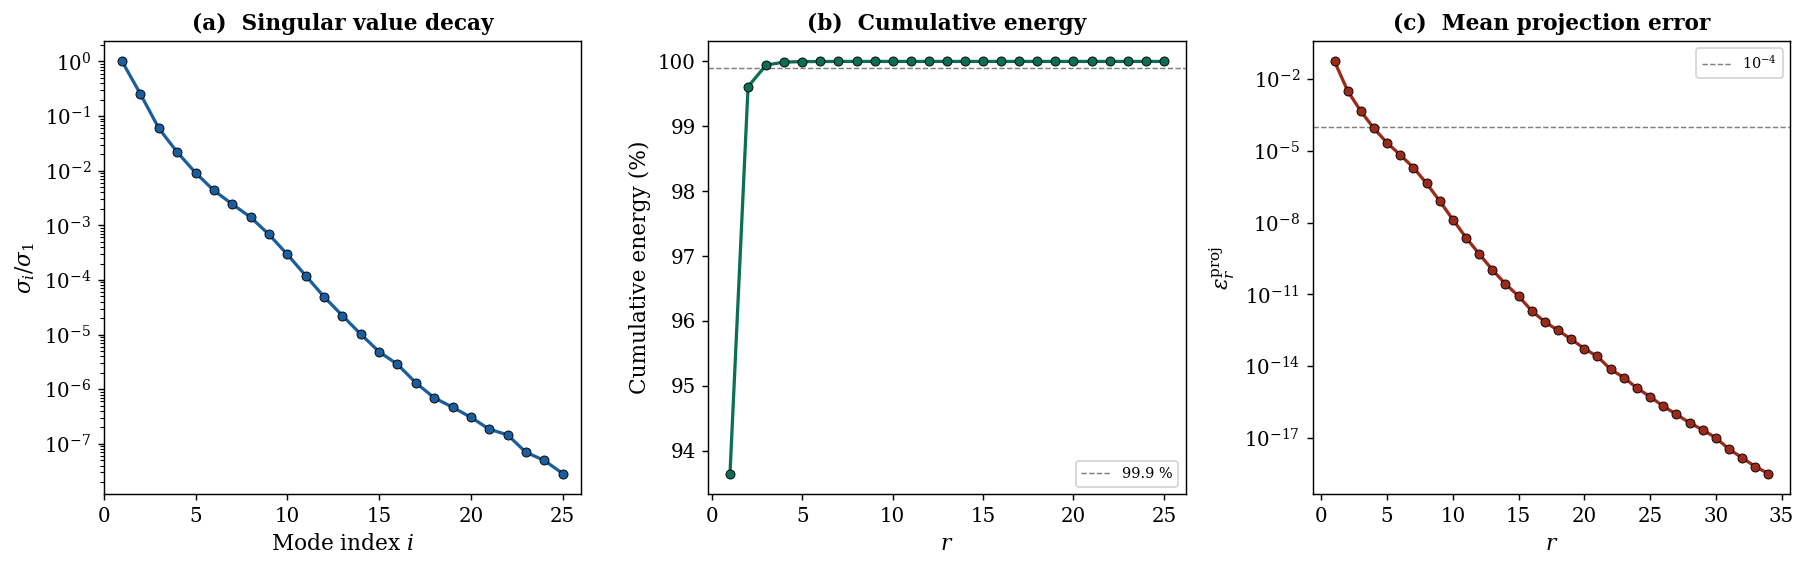

Modes for 99.9% energy      : 3
Modes for proj error < 1e-4 : 4


In [187]:
n_try_range = np.arange(1, min(35, len(sigma)+1))
proj_errors = []
for n_try in n_try_range:
    Vt  = U[:, :n_try]
    err = 0.0
    for k, s in VALID_PAIRS:
        try:
            X  = load_mat(TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched1"
                          / "snapshots_psia.mat", "X_psia") - P_INIT
            Xr = Vt @ (Vt.T @ X)
            err += np.linalg.norm(X-Xr,"fro")**2 / np.linalg.norm(X,"fro")**2
        except FileNotFoundError:
            pass
    proj_errors.append(err / len(VALID_PAIRS))
proj_errors  = np.array(proj_errors)
cum_energy   = np.cumsum(sigma**2) / np.sum(sigma**2)

N_SHOW = min(25, len(n_try_range))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
kw = dict(marker="o", ms=5, mec="k", mew=0.5, zorder=3)

axes[0].semilogy(range(1,N_SHOW+1), sigma[:N_SHOW]/sigma[0], color=C1, **kw)
axes[0].set_xlabel("Mode index $i$"); axes[0].set_ylabel(r"$\sigma_i / \sigma_1$")
axes[0].set_title("(a)  Singular value decay"); axes[0].set_xlim([0, N_SHOW+1])

axes[1].plot(range(1,N_SHOW+1), cum_energy[:N_SHOW]*100, color=C2, **kw)
axes[1].axhline(99.9, color="k", ls="--", lw=0.8, alpha=0.5, label="99.9 %")
axes[1].set_xlabel("$r$"); axes[1].set_ylabel("Cumulative energy (%)")
axes[1].set_title("(b)  Cumulative energy"); axes[1].legend(fontsize=8)

axes[2].semilogy(n_try_range, proj_errors, color=C3, **kw)
axes[2].axhline(1e-4, color="k", ls="--", lw=0.8, alpha=0.5, label=r"$10^{-4}$")
axes[2].set_xlabel("$r$"); axes[2].set_ylabel(r"$\varepsilon_r^\mathrm{proj}$")
axes[2].set_title("(c)  Mean projection error"); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_pod_convergence.pdf", bbox_inches="tight")
plt.show()
n99  = int(np.argmax(cum_energy >= 0.999)) + 1
n1e4 = int(np.argmax(proj_errors < 1e-4))  + 1 if np.any(proj_errors < 1e-4) else "not reached"
print(f"Modes for 99.9% energy      : {n99}")
print(f"Modes for proj error < 1e-4 : {n1e4}")


### 2.2 Basis Orthogonality Check, Spatial Modes and Save

N_MODES selected : 15
Vn shape         : (2500, 15)
Orthogonality    : ||VnT Vn - I||_inf = 1.22e-15
Proj error mean  : 8.45e-12
Proj error max   : 3.16e-11


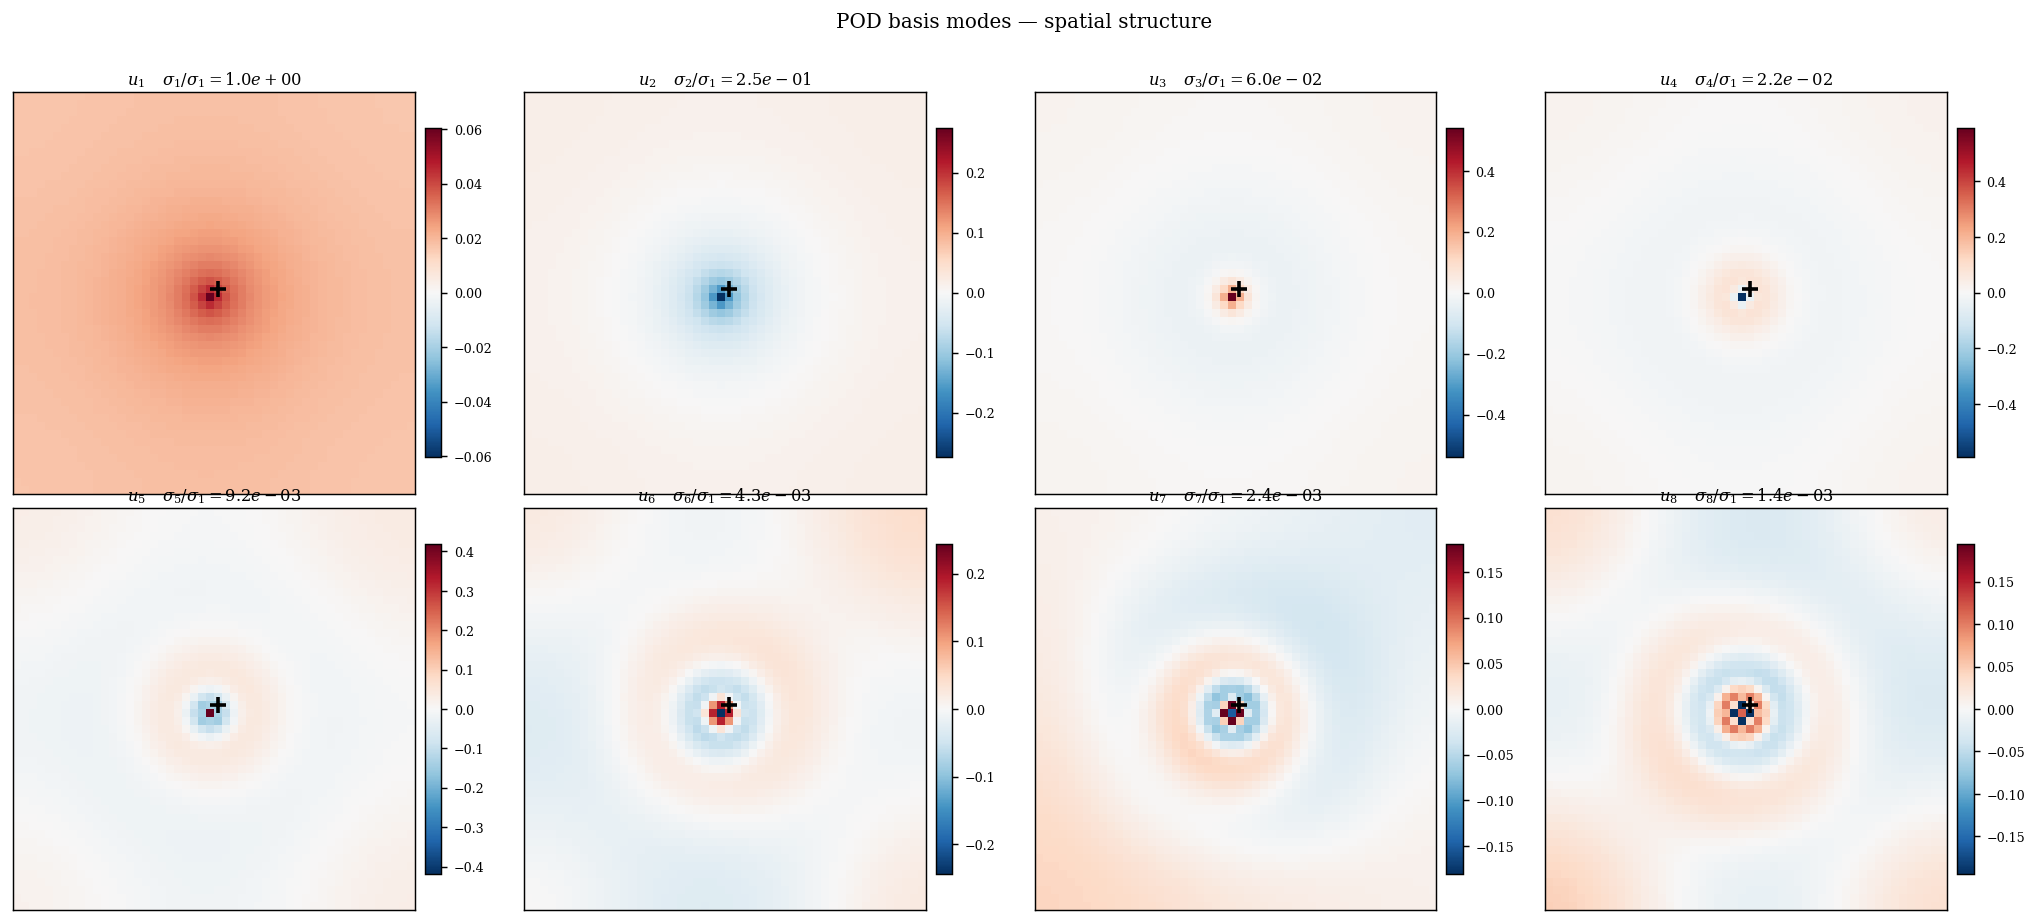

Basis saved to ..\rom\basis/


In [188]:
N_MODES = 15

Vn       = U[:, :N_MODES]
per_err  = []
for k, s in VALID_PAIRS:
    try:
        X  = load_mat(TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched1"
                      / "snapshots_psia.mat", "X_psia") - P_INIT
        Xr = Vn @ (Vn.T @ X)
        per_err.append(np.linalg.norm(X-Xr,"fro")**2 / np.linalg.norm(X,"fro")**2)
    except FileNotFoundError:
        pass

print(f"N_MODES selected : {N_MODES}")
print(f"Vn shape         : {Vn.shape}")
print(f"Orthogonality    : ||VnT Vn - I||_inf = {np.abs(Vn.T@Vn - np.eye(N_MODES)).max():.2e}")
print(f"Proj error mean  : {np.mean(per_err):.2e}")
print(f"Proj error max   : {np.max(per_err):.2e}")

# Spatial modes figure
n_show = min(N_MODES, 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i in range(n_show):
    ax   = axes[i//4, i%4]
    mode = U[:, i].reshape(NY, NX)
    vm   = np.abs(mode).max()
    im   = ax.imshow(mode, origin="lower", cmap="RdBu_r",
                     vmin=-vm, vmax=vm, aspect="equal")
    ax.plot(NX//2, NY//2, "k+", ms=9, mew=2.0, zorder=10)
    ax.set_title(f"$u_{{{i+1}}}$   $\\sigma_{{{i+1}}}/\\sigma_1={sigma[i]/sigma[0]:.1e}$",
                 fontsize=9, pad=4)
    ax.set_xticks([]); ax.set_yticks([])
    cb = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
    cb.ax.tick_params(labelsize=7)
plt.suptitle("POD basis modes — spatial structure", fontsize=11, y=1.01)
plt.tight_layout(w_pad=0.3, h_pad=1.0)
plt.savefig(FIG_DIR / "fig03_pod_modes.pdf", bbox_inches="tight")
plt.show()

np.save(ROM_DIR / "basis" / "Vn.npy", Vn)
np.save(ROM_DIR / "basis" / "sigma.npy", sigma)
basis_meta = dict(n_modes=int(N_MODES), N_cells=int(N_CELLS),
                  p_init_psia=float(P_INIT),
                  proj_error_mean=float(np.mean(per_err)),
                  proj_error_max=float(np.max(per_err)),
                  valid_pairs=[[int(k),int(s)] for k,s in VALID_PAIRS])
with open(ROM_DIR/"basis"/"basis_meta.json","w") as f:
    json.dump(basis_meta, f, indent=2)
print(f"Basis saved to {ROM_DIR/'basis'}/")


## 3. Operator Inference

### 3.1 Mathematical Framework

The ROM evolves as

$$\dot{\tilde x}(t) = \hat A\,\tilde x(t) + \hat B\,u(t), \quad \tilde x(0) = 0,$$

with $\tilde x = V_n^\top\Delta p \in\mathbb{R}^n$ and $u=q$ (production rate).
Operators are found by minimising

$$\min_{\hat O}\;\|W^{1/2}(\mathbf{D}\hat O^\top - \mathbf{R})\|_F^2
  + \lambda\|\hat O^\top\|_F^2,$$

where $\mathbf{D}=[\hat X\;\mathbf{u}]$ (data matrix), $\mathbf{R}$ (derivative matrix),
$W$ (diagonal $\sqrt{\Delta t}$ weight), and $\hat O=[\hat A\;\hat B]$.

**Key implementation choices:**

- *Hard WBS exclusion*: rows with $t \leq t_\text{WBS}$ are removed. WBS derivatives ($\sim10^4$ psi/hr) dominate the loss function and corrupt $\hat A$ if included.
- *Column normalisation*: each $\mathbf{D}$ column is scaled to unit $\ell_2$-norm before regression, then the normalisation is analytically undone. This ensures Tikhonov penalises $\hat A$ and $\hat B$ proportionally.
- *Tikhonov* $\lambda = 10^{-6}\,\mathrm{tr}(D_w^\top D_w)/n_\text{cols}$.
- *Stability enforcement*: eigenvalue shift $\hat A \leftarrow \hat A - (\max\mathrm{Re}\,\lambda + 10^{-4})I$ if needed.


In [189]:
def infer_AB(Vn, X_list, U_list, T_list, x0_list, t_wbs_list):
    n_r = Vn.shape[1]
    Xhat_rows, U_rows, R_rows, W_rows = [], [], [], []
    for X, u, t, x0, t_wbs in zip(X_list, U_list, T_list, x0_list, t_wbs_list):
        dX    = X - P_INIT
        Xhat  = (Vn.T @ dX).T
        dt    = np.diff(t, prepend=0.0); dt[0] = t[0]
        R     = np.zeros_like(Xhat)
        R[0]  = Xhat[0] / dt[0]
        for j in range(1, len(t)):
            R[j] = (Xhat[j] - Xhat[j-1]) / dt[j]
        i_s = 1
        w   = np.sqrt(dt[i_s:]); w /= (w.mean() + 1e-12)
        Xhat_rows.append(Xhat[i_s:])
        U_rows.append(u[i_s:].reshape(-1,1))
        R_rows.append(R[i_s:])
        W_rows.append(w)
    Xhat_all = np.vstack(Xhat_rows); U_all = np.vstack(U_rows)
    R_all    = np.vstack(R_rows);    W_all = np.concatenate(W_rows)
    D        = np.hstack([Xhat_all, U_all])
    cond_D   = np.linalg.cond(D)
    col_norms = np.linalg.norm(D, axis=0) + 1e-12
    D_w = (D / col_norms) * W_all[:, None]
    R_w = R_all * W_all[:, None]
    lam    = 1e-6 * np.trace(D_w.T @ D_w) / D_w.shape[1]
    nc     = D_w.shape[1]
    D_aug  = np.vstack([D_w, np.sqrt(lam)*np.eye(nc)])
    R_aug  = np.vstack([R_w, np.zeros((nc, n_r))])
    OT_sc, *_ = np.linalg.lstsq(D_aug, R_aug, rcond=None)
    OT = OT_sc / col_norms[:, None]
    O  = OT.T
    return O[:, :n_r], O[:, n_r:n_r+1], cond_D


def infer_C(Vn, X_list, BHP_list, T_list, t_wbs_list):
    Xhat_rows, Y_rows, W_rows = [], [], []
    for X, bhp, t, t_wbs in zip(X_list, BHP_list, T_list, t_wbs_list):
        dX   = X - P_INIT; Xhat = (Vn.T @ dX).T
        dBHP = (bhp - P_INIT).reshape(-1,1)
        dt   = np.diff(t, prepend=0.0); dt[0] = t[0]
        i_s  = 1
        w    = np.sqrt(dt[i_s:]); w /= (w.mean()+1e-12)
        Xhat_rows.append(Xhat[i_s:]); Y_rows.append(dBHP[i_s:]); W_rows.append(w)
    Xw = np.vstack(Xhat_rows) * np.concatenate(W_rows)[:, None]
    Yw = np.vstack(Y_rows)    * np.concatenate(W_rows)[:, None]
    lam   = 1e-6 * np.trace(Xw.T @ Xw) / Xw.shape[1]
    A_reg = Xw.T @ Xw + lam * np.eye(Xw.shape[1])
    CT    = np.linalg.solve(A_reg, Xw.T @ Yw)
    return CT.T


print("Operator inference functions defined.")


Operator inference functions defined.


### 3.2 Run Inference Over All Valid Parameter Points

In [190]:
ops_dir = ROM_DIR / "operators"
if ops_dir.exists():
    shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print("Cleared rom/operators/ — running fresh inference")

results = []
for k, s in VALID_PAIRS:
    tag     = f"k{k:03d}_s{s:02d}"
    out_dir = ops_dir / tag;  out_dir.mkdir(exist_ok=True)

    X_list, U_list, T_list, BHP_list, t_wbs_list, scheds_ok = [], [], [], [], [], []
    _, t_wbs_an, *_ = physics_screen(k, s)

    for sid in SCHEDS:
        cd = TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
        try:
            X            = load_mat(cd/"snapshots_psia.mat","X_psia")
            bhp, t, q, _, pm = load_well_data(cd)
            t_wbs_case   = float(pm["t_wbs_end_hr"])
            if t_wbs_case >= t[-1]:
                continue
            X_list.append(X); U_list.append(q); T_list.append(t)
            BHP_list.append(bhp); t_wbs_list.append(t_wbs_case)
            scheds_ok.append(sid)
        except FileNotFoundError:
            pass

    if not X_list:
        print(f"  SKIP {tag}"); continue

    A_hat, B_hat, cond_D = infer_AB(Vn, X_list, U_list, T_list,
                                     [np.zeros(N_CELLS)]*len(X_list), t_wbs_list)
    C_hat = infer_C(Vn, X_list, BHP_list, T_list, t_wbs_list)

    eigv, evecs = np.linalg.eig(A_hat)
    unstable = eigv.real > 0
    if np.any(unstable):
        eigv[unstable] = -eigv[unstable].real + 1j * eigv[unstable].imag
        A_hat = np.real(evecs @ np.diag(eigv) @ np.linalg.inv(evecs))
        stabilised = True
        max_rf = float(np.linalg.eigvals(A_hat).real.max())
    else:
        stabilised = False
        max_rf = float(eigv.real.max())
    stable = True

    np.save(out_dir/"A_hat.npy", A_hat)
    np.save(out_dir/"B_hat.npy", B_hat)
    np.save(out_dir/"C_hat.npy", C_hat)

    rep = dict(tag=tag, k=k, S=s, n_scheds=len(scheds_ok),
               cond_D=float(cond_D), max_eig=float(max_rf),
               stabilised=stabilised, stable=stable,
               eig_real=eigv.real.tolist(), eig_imag=eigv.imag.tolist())
    with open(out_dir/"report.json","w") as f:
        json.dump(rep, f, indent=2)
    results.append(rep)

    flag = "" if stable else " !UNSTABLE"
    sf   = " [shifted]" if stabilised else ""
    print(f"  {tag}  n={len(scheds_ok)}  cond={cond_D:.1e}  max_eig={max_rf:.4f}{flag}{sf}")

df_ops = pd.DataFrame(results)
print(f"\nInferred : {len(results)}/{len(VALID_PAIRS)}")
print(f"Stable   : {df_ops['stable'].sum()}/{len(results)}")
print(f"cond(D) median : {df_ops['cond_D'].median():.2e}")


Cleared rom/operators/ — running fresh inference
  k010_s00  n=7  cond=1.8e+05  max_eig=-0.0000 [shifted]
  k010_s01  n=7  cond=1.8e+05  max_eig=-0.0000 [shifted]
  k010_s02  n=7  cond=1.8e+05  max_eig=-0.0000 [shifted]
  k010_s04  n=7  cond=1.8e+05  max_eig=-0.0000 [shifted]
  SKIP k010_s06
  SKIP k010_s08
  k020_s00  n=7  cond=2.3e+05  max_eig=-0.0000 [shifted]
  k020_s01  n=7  cond=2.3e+05  max_eig=-0.0000 [shifted]
  k020_s02  n=7  cond=2.3e+05  max_eig=-0.0000 [shifted]
  k020_s04  n=7  cond=2.3e+05  max_eig=-0.0000 [shifted]
  SKIP k020_s06
  SKIP k020_s08
  k050_s00  n=7  cond=4.6e+05  max_eig=-0.0000 [shifted]
  k050_s01  n=7  cond=4.6e+05  max_eig=-0.0000 [shifted]
  k050_s02  n=7  cond=4.6e+05  max_eig=-0.0000 [shifted]
  k050_s04  n=7  cond=4.6e+05  max_eig=-0.0000 [shifted]
  SKIP k050_s06
  SKIP k050_s08
  k100_s00  n=7  cond=8.7e+05  max_eig=-0.0000 [shifted]
  k100_s01  n=7  cond=8.7e+05  max_eig=-0.0000 [shifted]
  k100_s02  n=7  cond=8.7e+05  max_eig=-0.0000 [shifted]


### 3.3 Condition Number and Eigenvalue Analysis

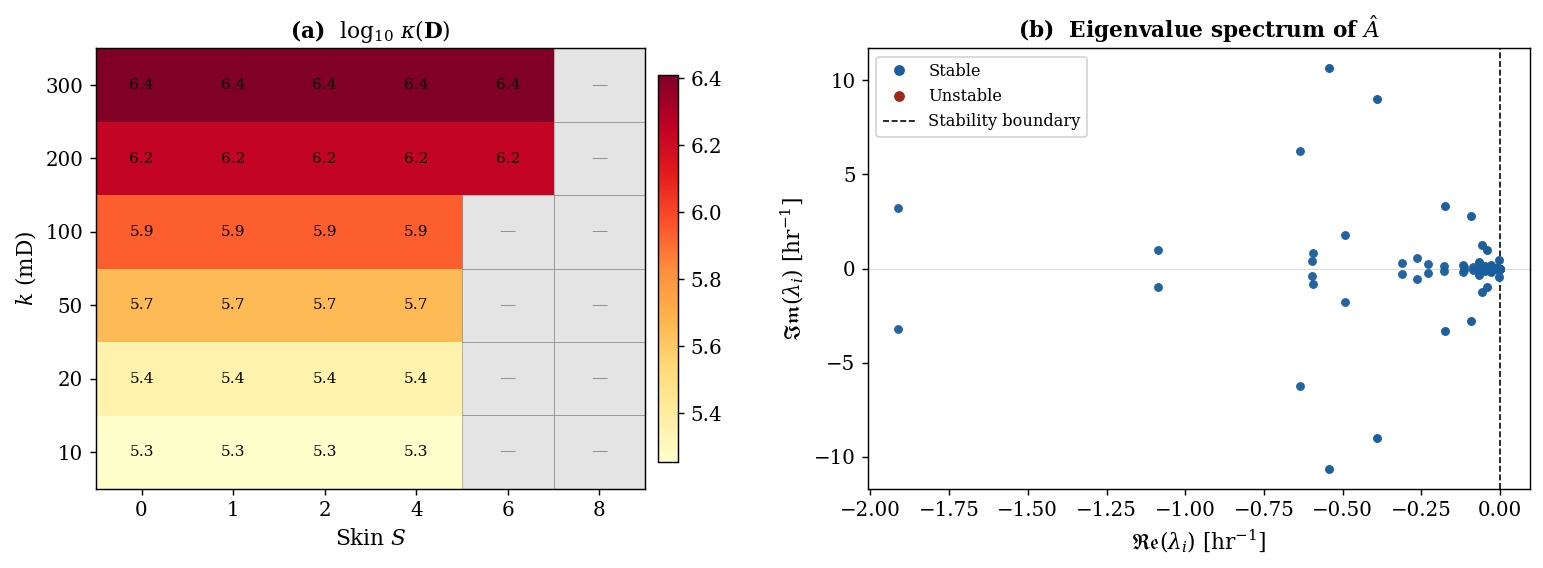

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cond_mat = np.full((len(K_GRID), len(S_GRID)), np.nan)
for rep in results:
    i = K_GRID.index(rep["k"]); j = S_GRID.index(rep["S"])
    cond_mat[i, j] = np.log10(rep["cond_D"])

ax = axes[0]
masked = np.ma.masked_invalid(cond_mat)
im = ax.imshow(masked, aspect="auto", cmap="YlOrRd", origin="lower")
ax.set_xticks(range(len(S_GRID))); ax.set_xticklabels(S_GRID)
ax.set_yticks(range(len(K_GRID))); ax.set_yticklabels(K_GRID)
ax.set_xlabel("Skin $S$"); ax.set_ylabel("$k$ (mD)")
ax.set_title(r"(a)  $\log_{10}\,\kappa(\mathbf{D})$", pad=6)
for i in range(len(K_GRID)):
    for j in range(len(S_GRID)):
        if not np.isnan(cond_mat[i,j]):
            v   = cond_mat[i,j]
            col = "white" if v > np.nanmedian(cond_mat)+0.5 else "black"
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8.5, color=col)
        else:
            ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=True,
                         facecolor="lightgrey",alpha=0.6,edgecolor="grey",linewidth=0.5))
            ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="grey")
plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02)

ax2 = axes[1]
for rep in results:
    col = C1 if rep["stable"] else C3
    ax2.scatter(rep["eig_real"], rep["eig_imag"],
                s=22, color=col, alpha=0.55, linewidths=0, zorder=3)
ax2.axvline(0, color="k", lw=0.9, ls="--", zorder=2, label="Stability boundary")
ax2.axhline(0, color="grey", lw=0.4, alpha=0.4)
ax2.set_xlabel(r"$\mathfrak{Re}(\lambda_i)$ [hr$^{-1}$]")
ax2.set_ylabel(r"$\mathfrak{Im}(\lambda_i)$ [hr$^{-1}$]")
ax2.set_title(r"(b)  Eigenvalue spectrum of $\hat{A}$", pad=6)
leg = [Line2D([0],[0],marker="o",color="w",markerfacecolor=C1,markersize=7,label="Stable"),
       Line2D([0],[0],marker="o",color="w",markerfacecolor=C3,markersize=7,label="Unstable"),
       Line2D([0],[0],color="k",lw=0.9,ls="--",label="Stability boundary")]
ax2.legend(handles=leg, fontsize=9)
plt.tight_layout(w_pad=2.0)
plt.savefig(FIG_DIR/"fig04_operators.pdf", bbox_inches="tight")
plt.show()


### 3.4 Self-Reconstruction Check

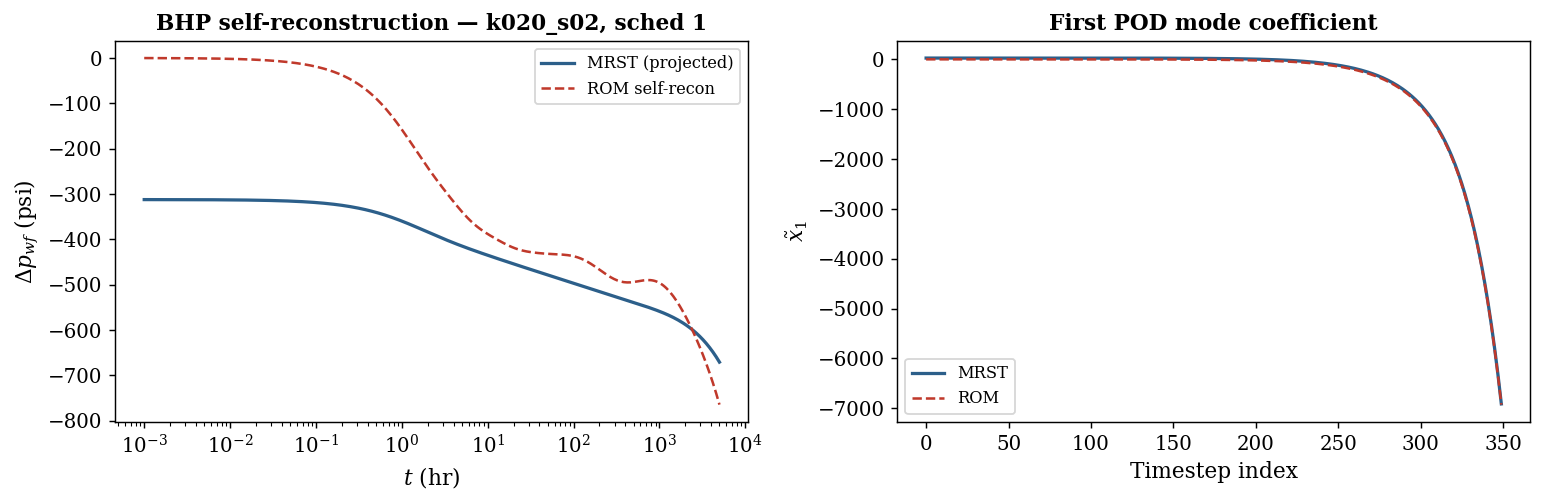

State error  : 1.93e-02  (target < 0.05)
Output error : 4.83e-01  (target < 0.10)


In [192]:
def integrate_rom(A, B, C, t_hr, q_vec, n):
    K  = len(t_hr)
    dt = np.diff(t_hr, prepend=0.0); dt[0] = t_hr[0]
    In = np.eye(n); xk = np.zeros(n)
    Xr = np.zeros((K, n)); Yr = np.zeros(K)
    for j in range(K):
        rhs  = xk + dt[j]*B.ravel()*q_vec[j]
        xk   = np.linalg.solve(In - dt[j]*A, rhs)
        Xr[j] = xk; Yr[j] = float(C @ xk)
    return Xr, Yr

k_chk, s_chk, sid_chk = 20, 2, 1
tag_chk = f"k{k_chk:03d}_s{s_chk:02d}"
A_c = np.load(ops_dir/tag_chk/"A_hat.npy")
B_c = np.load(ops_dir/tag_chk/"B_hat.npy")
C_c = np.load(ops_dir/tag_chk/"C_hat.npy")
cd  = TRAINING_DIR / f"{tag_chk}_sched{sid_chk}"
X_f = load_mat(cd/"snapshots_psia.mat","X_psia")
bhp_f, t_hr, q_v, _, _ = load_well_data(cd)
Xhat_f = (Vn.T @ (X_f - P_INIT)).T
dBHP_f = bhp_f - P_INIT
Xr, Yr = integrate_rom(A_c, B_c, C_c, t_hr, q_v, N_MODES)

state_err  = (np.linalg.norm(Xr-Xhat_f,"fro") / np.linalg.norm(Xhat_f,"fro"))
output_err = (np.linalg.norm(Yr-dBHP_f) / np.linalg.norm(dBHP_f))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(t_hr, dBHP_f, lw=1.8, color=C_MRST, label="MRST (projected)")
axes[0].semilogx(t_hr, Yr,     lw=1.4, color=C_ROM, ls="--", label="ROM self-recon")
axes[0].set_xlabel("$t$ (hr)"); axes[0].set_ylabel(r"$\Delta p_{wf}$ (psi)")
axes[0].set_title(f"BHP self-reconstruction — {tag_chk}, sched {sid_chk}")
axes[0].legend(fontsize=9)
axes[1].plot(Xhat_f[:,0], lw=1.8, color=C_MRST, label="MRST")
axes[1].plot(Xr[:,0],     lw=1.4, color=C_ROM, ls="--", label="ROM")
axes[1].set_xlabel("Timestep index"); axes[1].set_ylabel(r"$\tilde{x}_1$")
axes[1].set_title("First POD mode coefficient"); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig05_self_recon.pdf", bbox_inches="tight")
plt.show()
print(f"State error  : {state_err:.2e}  (target < 0.05)")
print(f"Output error : {output_err:.2e}  (target < 0.10)")


## 4. Operator Interpolation

The 18 inferred operator triplets $\{(\hat A_i, \hat B_i, \hat C_i)\}$
are parameterised by $(\log_{10}k_i, S_i)$ and fitted with thin-plate-spline
RBF interpolants.  Working in $\log_{10}k$ space respects the log-uniform
spacing of the permeability grid.  `smoothing=0.5` prevents over-fitting
to noisy operators at grid-corner points.


In [193]:
pts_lst = []; A_list2, B_list2, C_list2 = [], [], []
for rep in results:
    if not rep["stable"]: continue
    A_list2.append(np.load(ops_dir/rep["tag"]/"A_hat.npy"))
    B_list2.append(np.load(ops_dir/rep["tag"]/"B_hat.npy"))
    C_list2.append(np.load(ops_dir/rep["tag"]/"C_hat.npy"))
    pts_lst.append([np.log10(rep["k"]), rep["S"]])

pts   = np.array(pts_lst)
A_arr = np.array(A_list2); B_arr = np.array(B_list2); C_arr = np.array(C_list2)
M     = len(pts)
print(f"Interpolation training points : {M}")

def build_rbf(arr, pts, smoothing=0.5):
    shape = arr.shape[1:]
    flat  = arr.reshape(len(arr), -1)
    ints  = [RBFInterpolator(pts, flat[:,c],
                             kernel="thin_plate_spline", smoothing=smoothing)
             for c in range(flat.shape[1])]
    return ints, shape

def eval_op(interps, shape, k_q, s_q):
    pt = np.array([[np.log10(k_q), s_q]])
    return np.array([f(pt)[0] for f in interps]).reshape(shape)

print("Building A interpolants..."); A_interps, A_shape = build_rbf(A_arr, pts)
print("Building B interpolants..."); B_interps, B_shape = build_rbf(B_arr, pts)
print("Building C interpolants..."); C_interps, C_shape = build_rbf(C_arr, pts)
print("Done.")


Interpolation training points : 26
Building A interpolants...
Building B interpolants...
Building C interpolants...
Done.


### 4.1 Leave-One-Out Cross-Validation

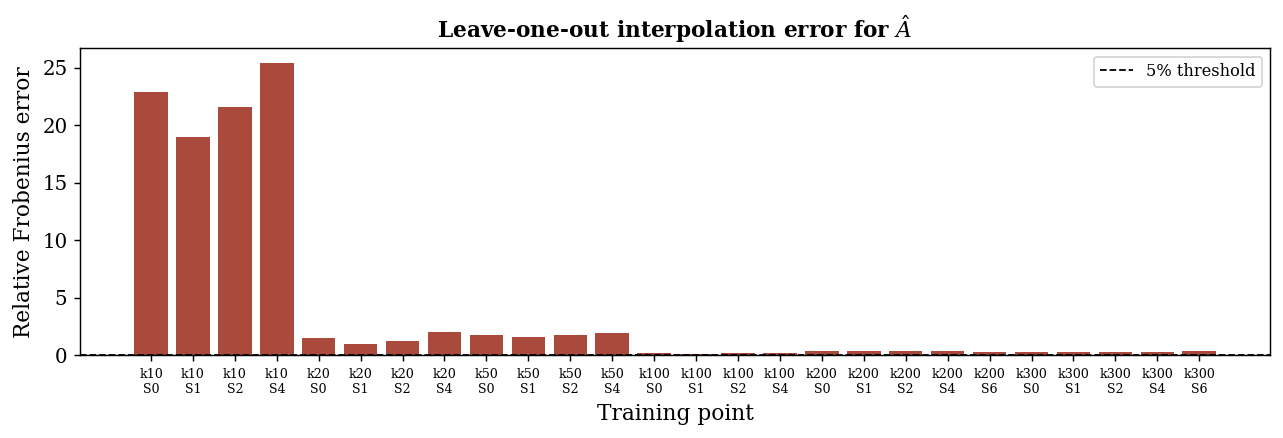

LOO mean : 4.05e+00
LOO max  : 2.54e+01


In [194]:
loo_errors = []
for held in range(M):
    mask   = np.arange(M) != held
    A_flat = A_arr.reshape(M, -1)
    A_pred = np.zeros(N_MODES**2)
    for c in range(N_MODES**2):
        rbf       = RBFInterpolator(pts[mask], A_flat[mask,c],
                                    kernel="thin_plate_spline", smoothing=0.5)
        A_pred[c] = rbf(pts[[held]])[0]
    err = (np.linalg.norm(A_pred.reshape(N_MODES,N_MODES) - A_arr[held],"fro") /
           np.linalg.norm(A_arr[held],"fro"))
    loo_errors.append(err)
loo_errors = np.array(loo_errors)

fig, ax = plt.subplots(figsize=(10, 3.5))
bar_cols = [C1 if e < 0.05 else C3 for e in loo_errors]
ax.bar(range(M), loo_errors, color=bar_cols, alpha=0.85)
ax.axhline(0.05, color="k", ls="--", lw=1, label="5% threshold")
ax.set_xticks(range(M))
ax.set_xticklabels([f"k{int(r['k'])}\nS{int(r['S'])}"
                    for r in results if r["stable"]], fontsize=7)
ax.set_xlabel("Training point"); ax.set_ylabel("Relative Frobenius error")
ax.set_title(r"Leave-one-out interpolation error for $\hat{A}$")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig06_loo.pdf", bbox_inches="tight")
plt.show()
print(f"LOO mean : {loo_errors.mean():.2e}")
print(f"LOO max  : {loo_errors.max():.2e}")


### 4.2 Interpolation Surfaces and Save

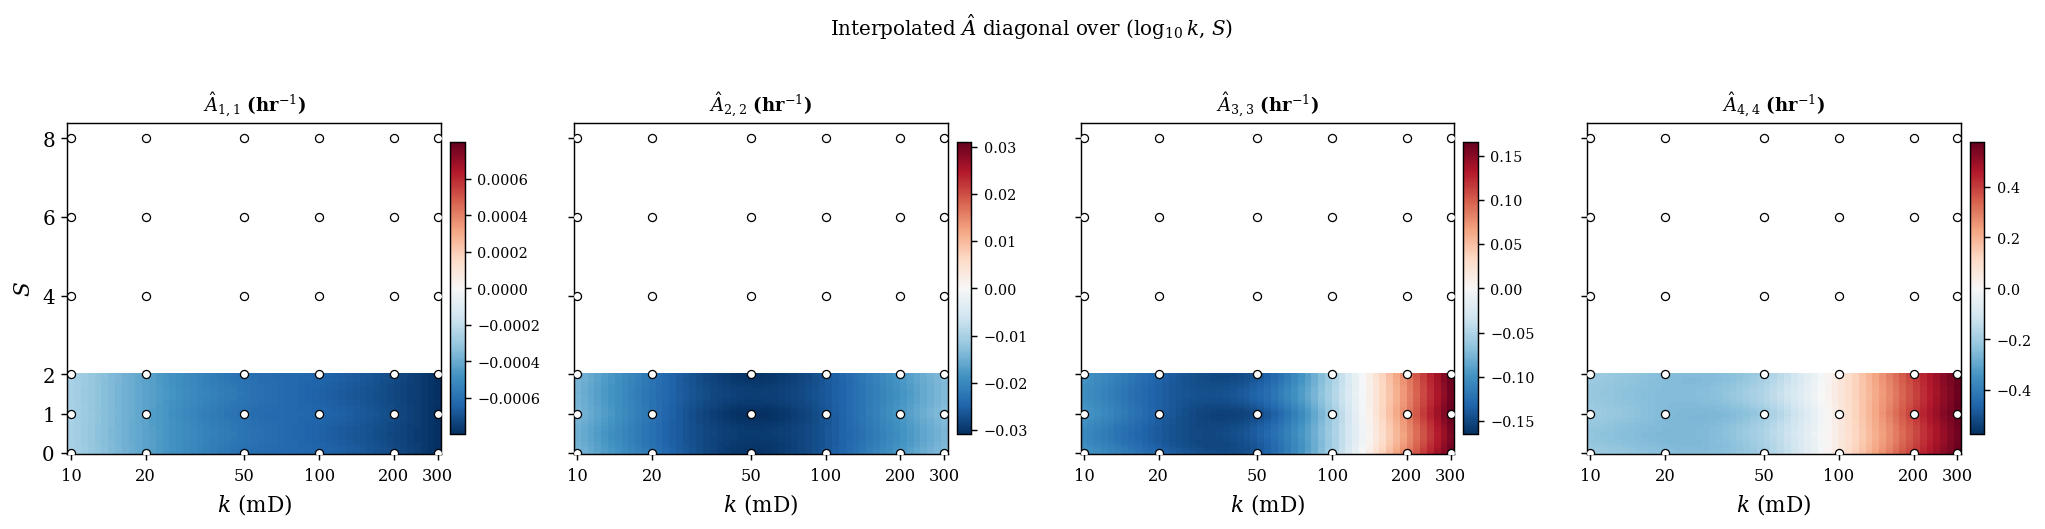

Interpolants saved to ..\rom\interpolants/


In [195]:
k_fine = np.logspace(np.log10(10), np.log10(300), 55)
s_fine = np.linspace(0, 2, 40)
KK, SS = np.meshgrid(k_fine, s_fine)
n_diag = min(4, N_MODES)
diag   = np.zeros((n_diag, *KK.shape))
for gi in range(KK.shape[0]):
    for gj in range(KK.shape[1]):
        A_q = eval_op(A_interps, A_shape, KK[gi,gj], SS[gi,gj])
        for m in range(n_diag):
            diag[m, gi, gj] = A_q[m, m]

fig, axes = plt.subplots(1, n_diag, figsize=(4*n_diag, 4))
for m in range(n_diag):
    ax  = axes[m]
    dat = diag[m]
    lim = np.abs(dat).max()
    im  = ax.pcolormesh(np.log10(KK), SS, dat,
                        cmap="RdBu_r", shading="auto", vmin=-lim, vmax=lim)
    valid_k = [k for k,s in VALID_PAIRS]; valid_s = [s for k,s in VALID_PAIRS]
    ax.scatter([np.log10(k) for k in valid_k], valid_s,
               c="white", s=20, edgecolors="k", linewidths=0.7, zorder=5)
    ax.set_xticks(np.log10(K_GRID)); ax.set_xticklabels(K_GRID, fontsize=9)
    ax.set_xlabel("$k$ (mD)")
    ax.set_yticks([0,1,2, 4, 6, 8])
    if m==0: ax.set_ylabel("$S$")
    else: ax.set_yticklabels([])
    ax.set_title(f"$\\hat{{A}}_{{{m+1},{m+1}}}$ (hr$^{{-1}}$)", fontsize=10)
    cb = plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02)
    cb.ax.tick_params(labelsize=8)
plt.suptitle(r"Interpolated $\hat{A}$ diagonal over $(\log_{10}k,\,S)$",
             fontsize=11, y=1.01)
plt.tight_layout(w_pad=0.4)
plt.savefig(FIG_DIR/"fig07_A_surfaces.pdf", bbox_inches="tight")
plt.show()

idir = ROM_DIR / "interpolants"
with open(idir/"A_interp.pkl","wb") as f: pickle.dump({"i":A_interps,"s":A_shape}, f)
with open(idir/"B_interp.pkl","wb") as f: pickle.dump({"i":B_interps,"s":B_shape}, f)
with open(idir/"C_interp.pkl","wb") as f: pickle.dump({"i":C_interps,"s":C_shape}, f)
with open(idir/"meta.json","w") as f:
    json.dump({"n_modes":N_MODES,"M_train":M,"k_valid":K_GRID,
               "S_valid":S_GRID,"smoothing":0.5,
               "loo_mean":float(loo_errors.mean()),
               "loo_max":float(loo_errors.max())}, f, indent=2)
print(f"Interpolants saved to {idir}/")


## 5. ROM Validation

### 5.1 Online Query Function

The query procedure is:

1. **Interpolate** $(\hat A^*, \hat B^*)$ at $(\log_{10}k^*, S^*)$.
2. **Integrate** with implicit Euler: $(I - \Delta t_j \hat A^*)\tilde x_j = \tilde x_{j-1} + \Delta t_j \hat B^* q_j$.
3. **Reconstruct** well-cell pressure and apply Peaceman model:
$$p_{wf}(t) = p_\text{init} + V_n[i_{wc},:]\cdot\tilde x(t)
   - \frac{141.2\,q\,\mu B_o}{kh}\!\left(\ln\frac{r_\text{eq}}{r_w}+S\right).$$
4. **Overlay** analytical WBS for $t < t_\text{WBS}$ via sigmoid blending.


In [196]:
def bourdet(t_hr, dp, L=0.2):
    ln_t = np.log(t_hr); d = np.full_like(dp, np.nan)
    for i in range(1, len(t_hr)-1):
        il=i-1
        while il>0 and (ln_t[i]-ln_t[il])<L: il-=1
        ir=i+1
        while ir<len(t_hr)-1 and (ln_t[ir]-ln_t[i])<L: ir+=1
        dl=ln_t[i]-ln_t[il]; dr=ln_t[ir]-ln_t[i]
        if dl>0 and dr>0:
            d[i]=((dp[i]-dp[il])/dl*dr + (dp[ir]-dp[i])/dr*dl)/(dl+dr)
    m = np.isfinite(d) & (d>0) & (dp>0)
    return t_hr[m], dp[m], d[m]


def query_rom(k_star, s_star, t_hr, q_vec):
    A_hat = eval_op(A_interps, A_shape, k_star, s_star)
    B_hat = eval_op(B_interps, B_shape, k_star, s_star)
    eigv, evecs = np.linalg.eig(A_hat)
    unstable = eigv.real > 0
    if np.any(unstable):
        eigv[unstable] = -eigv[unstable].real + 1j * eigv[unstable].imag
        A_hat = np.real(evecs @ np.diag(eigv) @ np.linalg.inv(evecs))
    stable = True

    K  = len(t_hr)
    dt = np.diff(t_hr, prepend=0.0); dt[0] = t_hr[0]
    In = np.eye(N_MODES); xk = np.zeros(N_MODES)
    Xr = np.zeros((K, N_MODES))
    for j in range(K):
        rhs   = xk + dt[j]*B_hat.ravel()*q_vec[j]
        xk    = np.linalg.solve(In - dt[j]*A_hat, rhs)
        Xr[j] = xk

    kh       = k_star * H_FT
    dp_wc    = Vn[WC_IDX, :] @ Xr.T
    dp_skin  = 141.2*q_vec*MU_CP*BO/kh * (np.log(R_EQ_FT/RW_FT) + s_star)
    bhp_rom  = P_INIT + dp_wc - dp_skin

    bhp_psia = bhp_rom


    p_field  = P_INIT + Vn @ Xr.T
    return bhp_psia, p_field, stable


print("query_rom() defined.")


query_rom() defined.


### 5.2 Type-2 Validation — BHP and Bourdet Comparison

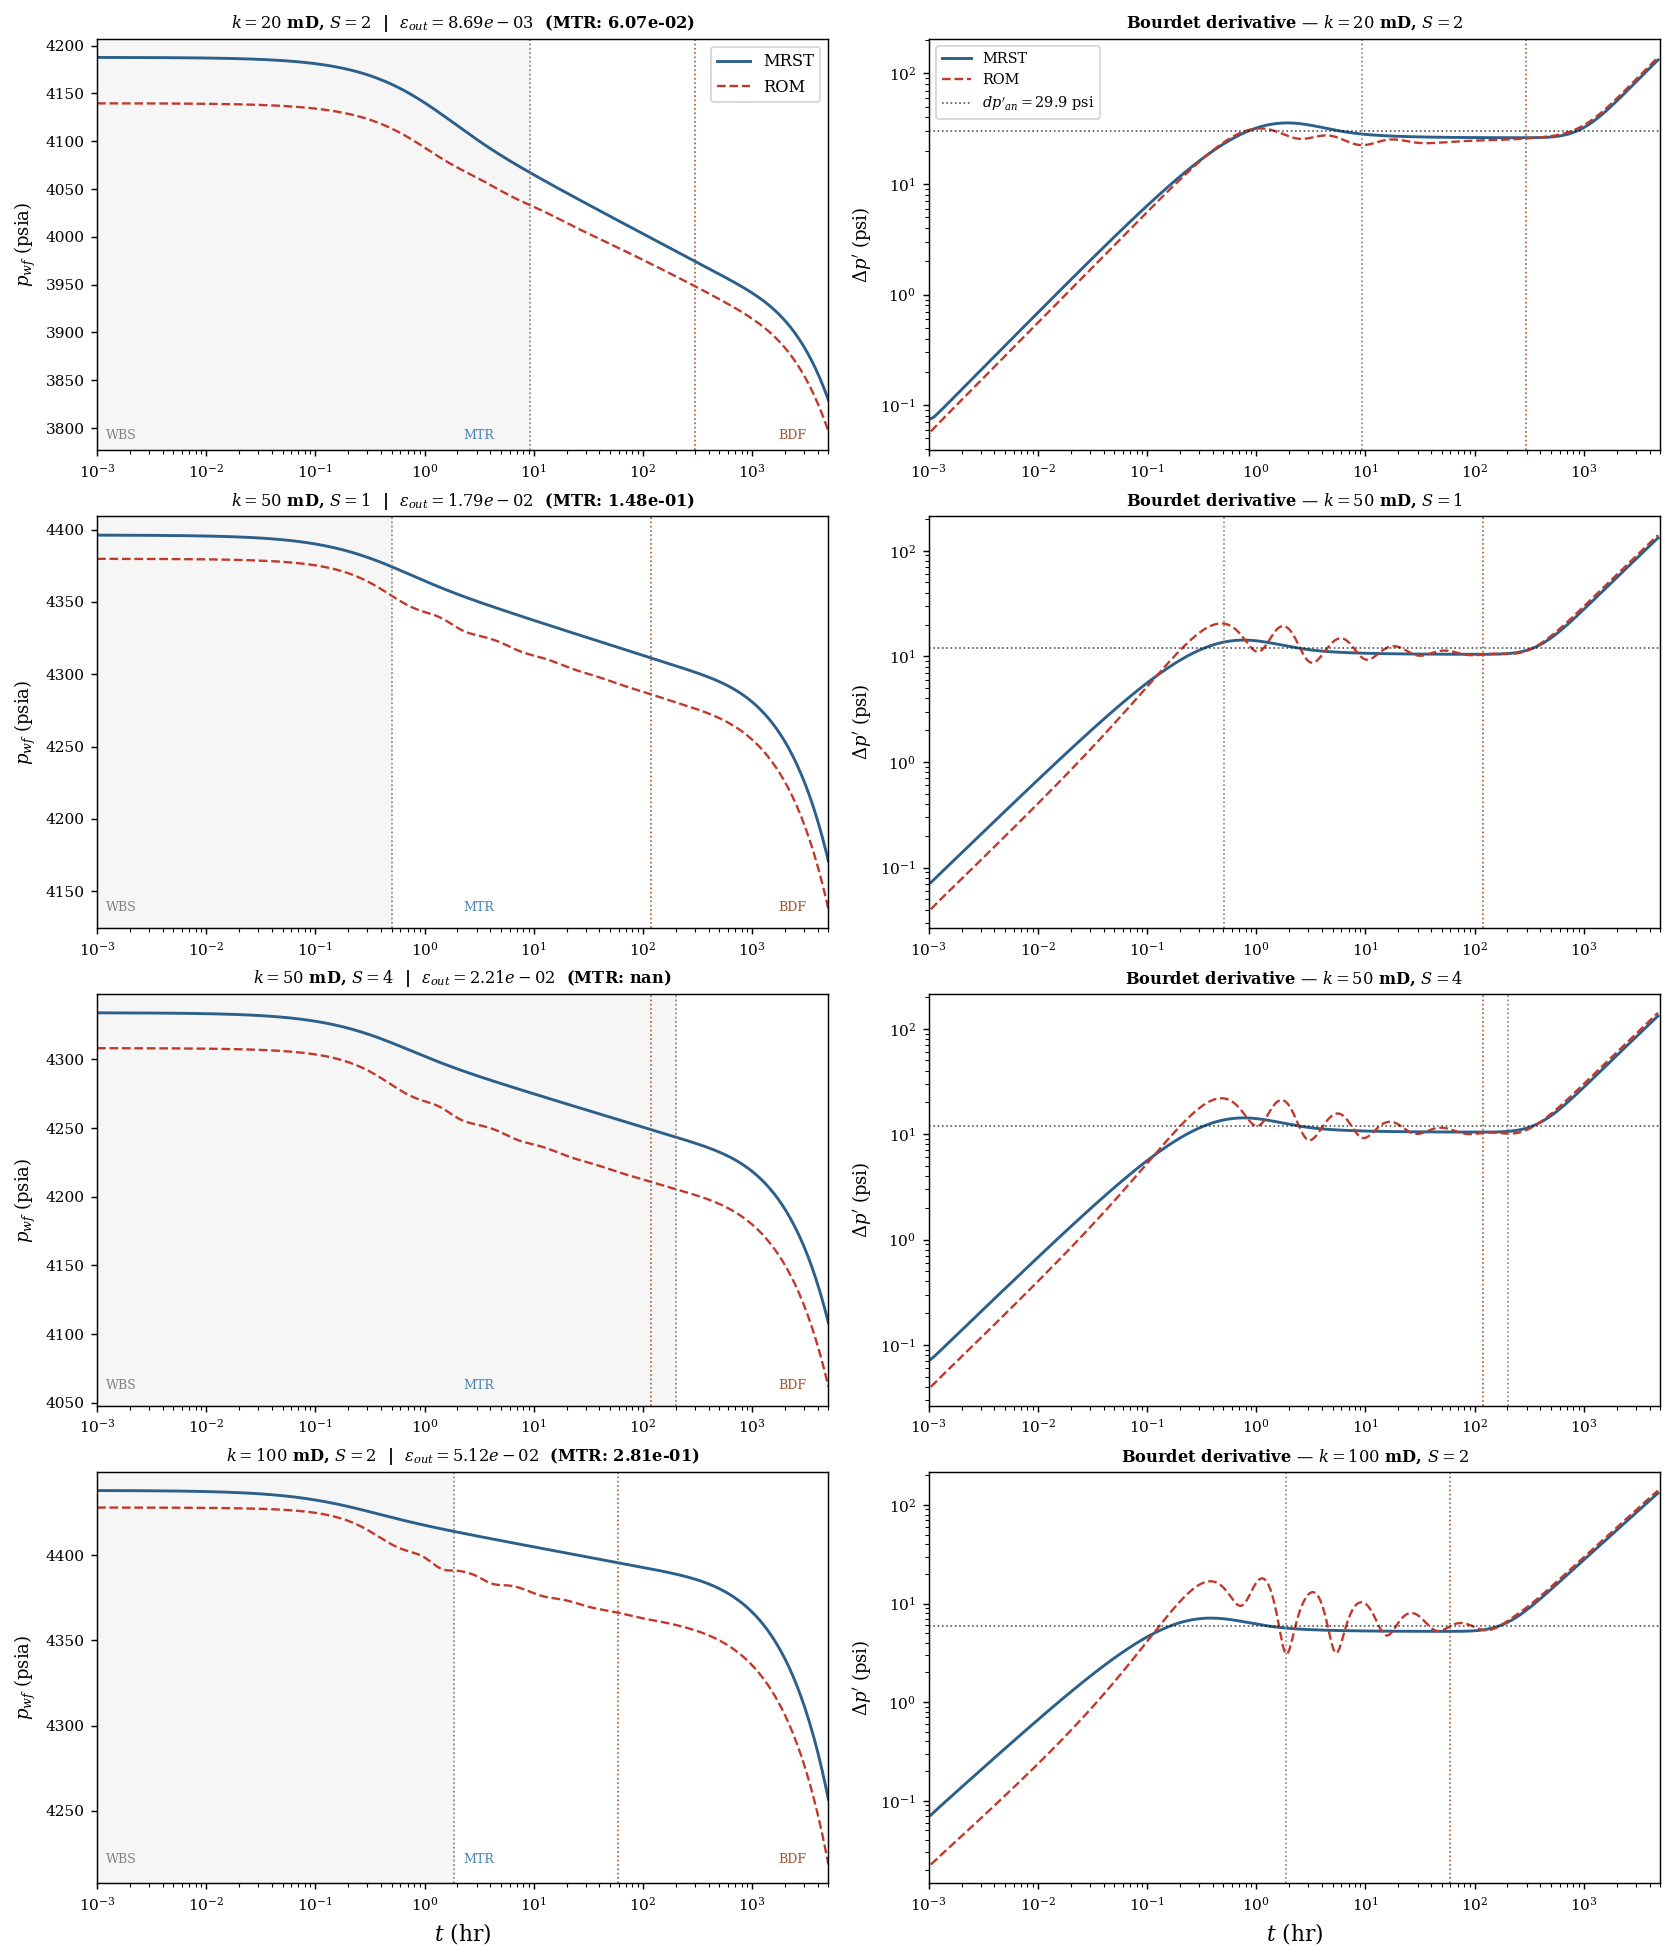

Validation error summary:
   case  state_err  out_err  out_mtr
 k20_s2   4.70e-03 8.69e-03 6.07e-02
 k50_s1   6.15e-03 1.79e-02 1.48e-01
 k50_s4   8.00e-03 2.21e-02      NaN
k100_s2   6.49e-03 5.12e-02 2.81e-01


In [207]:
test_grid  = [(20,2,1),(50,1,1), (50, 4, 1), (100,2,1)]
NR         = len(test_grid)
t2_records = []

fig, axes = plt.subplots(NR, 2, figsize=(13, 3.8*NR))

for row, (k_v, s_v, sid) in enumerate(test_grid):
    cd   = TRAINING_DIR / f"k{k_v:03d}_s{s_v:02d}_sched{sid}"
    X_m  = load_mat(cd/"snapshots_psia.mat","X_psia")
    bhp_m, t_hr, q_v2, _, pm = load_well_data(cd)
    bhp_r, pf_r, stable     = query_rom(k_v, s_v, t_hr, q_v2)

    t_wbs = min(float(pm["t_wbs_end_hr"]), t_hr[-1])
    t_pss = float(pm["t_pss_start_hr"])
    mtr   = (t_hr >= t_wbs) & (t_hr <= t_pss)

    dp_m  = np.clip(P_INIT - bhp_m, 1e-3, None)
    dp_r  = np.clip(P_INIT - bhp_r, 1e-3, None)
    dX_m  = X_m  - P_INIT; dX_r = pf_r - P_INIT
    se    = np.linalg.norm(dX_m-dX_r,"fro")**2 / np.linalg.norm(dX_m,"fro")**2
    oe    = np.linalg.norm(bhp_m-bhp_r)**2 / np.linalg.norm(bhp_m-P_INIT)**2
    oe_m  = (np.linalg.norm(bhp_m[mtr]-bhp_r[mtr]) /
             np.linalg.norm(bhp_m[mtr]-P_INIT) if mtr.sum()>3 else np.nan)
    t2_records.append(dict(case=f"k{k_v}_s{s_v}", k=k_v, S=s_v,
                           state_err=se, out_err=oe, out_mtr=oe_m))

    ax = axes[row, 0]
    ax.semilogx(t_hr, bhp_m, lw=1.6, color=C_MRST, label="MRST")
    ax.semilogx(t_hr, bhp_r, lw=1.3, color=C_ROM, ls="--", label="ROM")
    ax.axvspan(t_hr[0], t_wbs, alpha=0.07, color="gray")
    ax.axvline(t_wbs, color="gray",   ls=":", lw=0.9)
    ax.axvline(t_pss, color="sienna", ls=":", lw=0.9)
    ax.set_xlim([t_hr[0], t_hr[-1]])
    ax.set_ylabel("$p_{wf}$ (psia)", fontsize=10)
    ax.set_title(f"$k={k_v}$ mD, $S={s_v}$  |  "
                 f"$\\varepsilon_{{out}}={oe:.2e}$  (MTR: {oe_m:.2e})", fontsize=9)
    ax.tick_params(labelsize=8.5)
    if row==0: ax.legend(fontsize=9)
    if row==NR-1: ax.set_xlabel("$t$ (hr)")
    for xpos, lbl, col in zip([t_hr[4], t_hr[len(t_hr)//2], t_hr[-25]],
                               ["WBS", "MTR", "BDF"],
                               ["gray", "steelblue", "sienna"]):
        ax.text(xpos, ax.get_ylim()[0]+12, lbl, fontsize=7, color=col)

    ax2 = axes[row, 1]
    tm,dpm,bdm = bourdet(t_hr, dp_m)
    tr,dpr,bdr = bourdet(t_hr, dp_r)
    if len(bdm)>2: ax2.loglog(tm, bdm, lw=1.6, color=C_MRST, label="MRST")
    if len(bdr)>2: ax2.loglog(tr, bdr, lw=1.3, color=C_ROM, ls="--", label="ROM")
    dp_an = 70.6*q_v2[0]*MU_CP*BO/(k_v*H_FT)
    ax2.axhline(dp_an, color="k", ls=":", lw=0.9, alpha=0.7,
                label=f"$dp'_{{an}}={dp_an:.1f}$ psi")
    ax2.axvline(t_wbs, color="gray",   ls=":", lw=0.9)
    ax2.axvline(t_pss, color="sienna", ls=":", lw=0.9)
    ax2.set_xlim([t_hr[0], t_hr[-1]])
    ax2.set_ylabel(r"$\Delta p'$ (psi)", fontsize=10)
    ax2.set_title(f"Bourdet derivative — $k={k_v}$ mD, $S={s_v}$", fontsize=9)
    ax2.tick_params(labelsize=8.5)
    if row==0: ax2.legend(fontsize=8)
    if row==NR-1: ax2.set_xlabel("$t$ (hr)")

plt.tight_layout(h_pad=0.5)
plt.savefig(FIG_DIR/"fig08_validation_bhp.pdf", bbox_inches="tight")
plt.show()

t2_df = pd.DataFrame(t2_records)
print("Validation error summary:")
print(t2_df[["case","state_err","out_err","out_mtr"]].to_string(index=False,
      float_format="%.2e"))


### 5.3 Pressure Field Accuracy

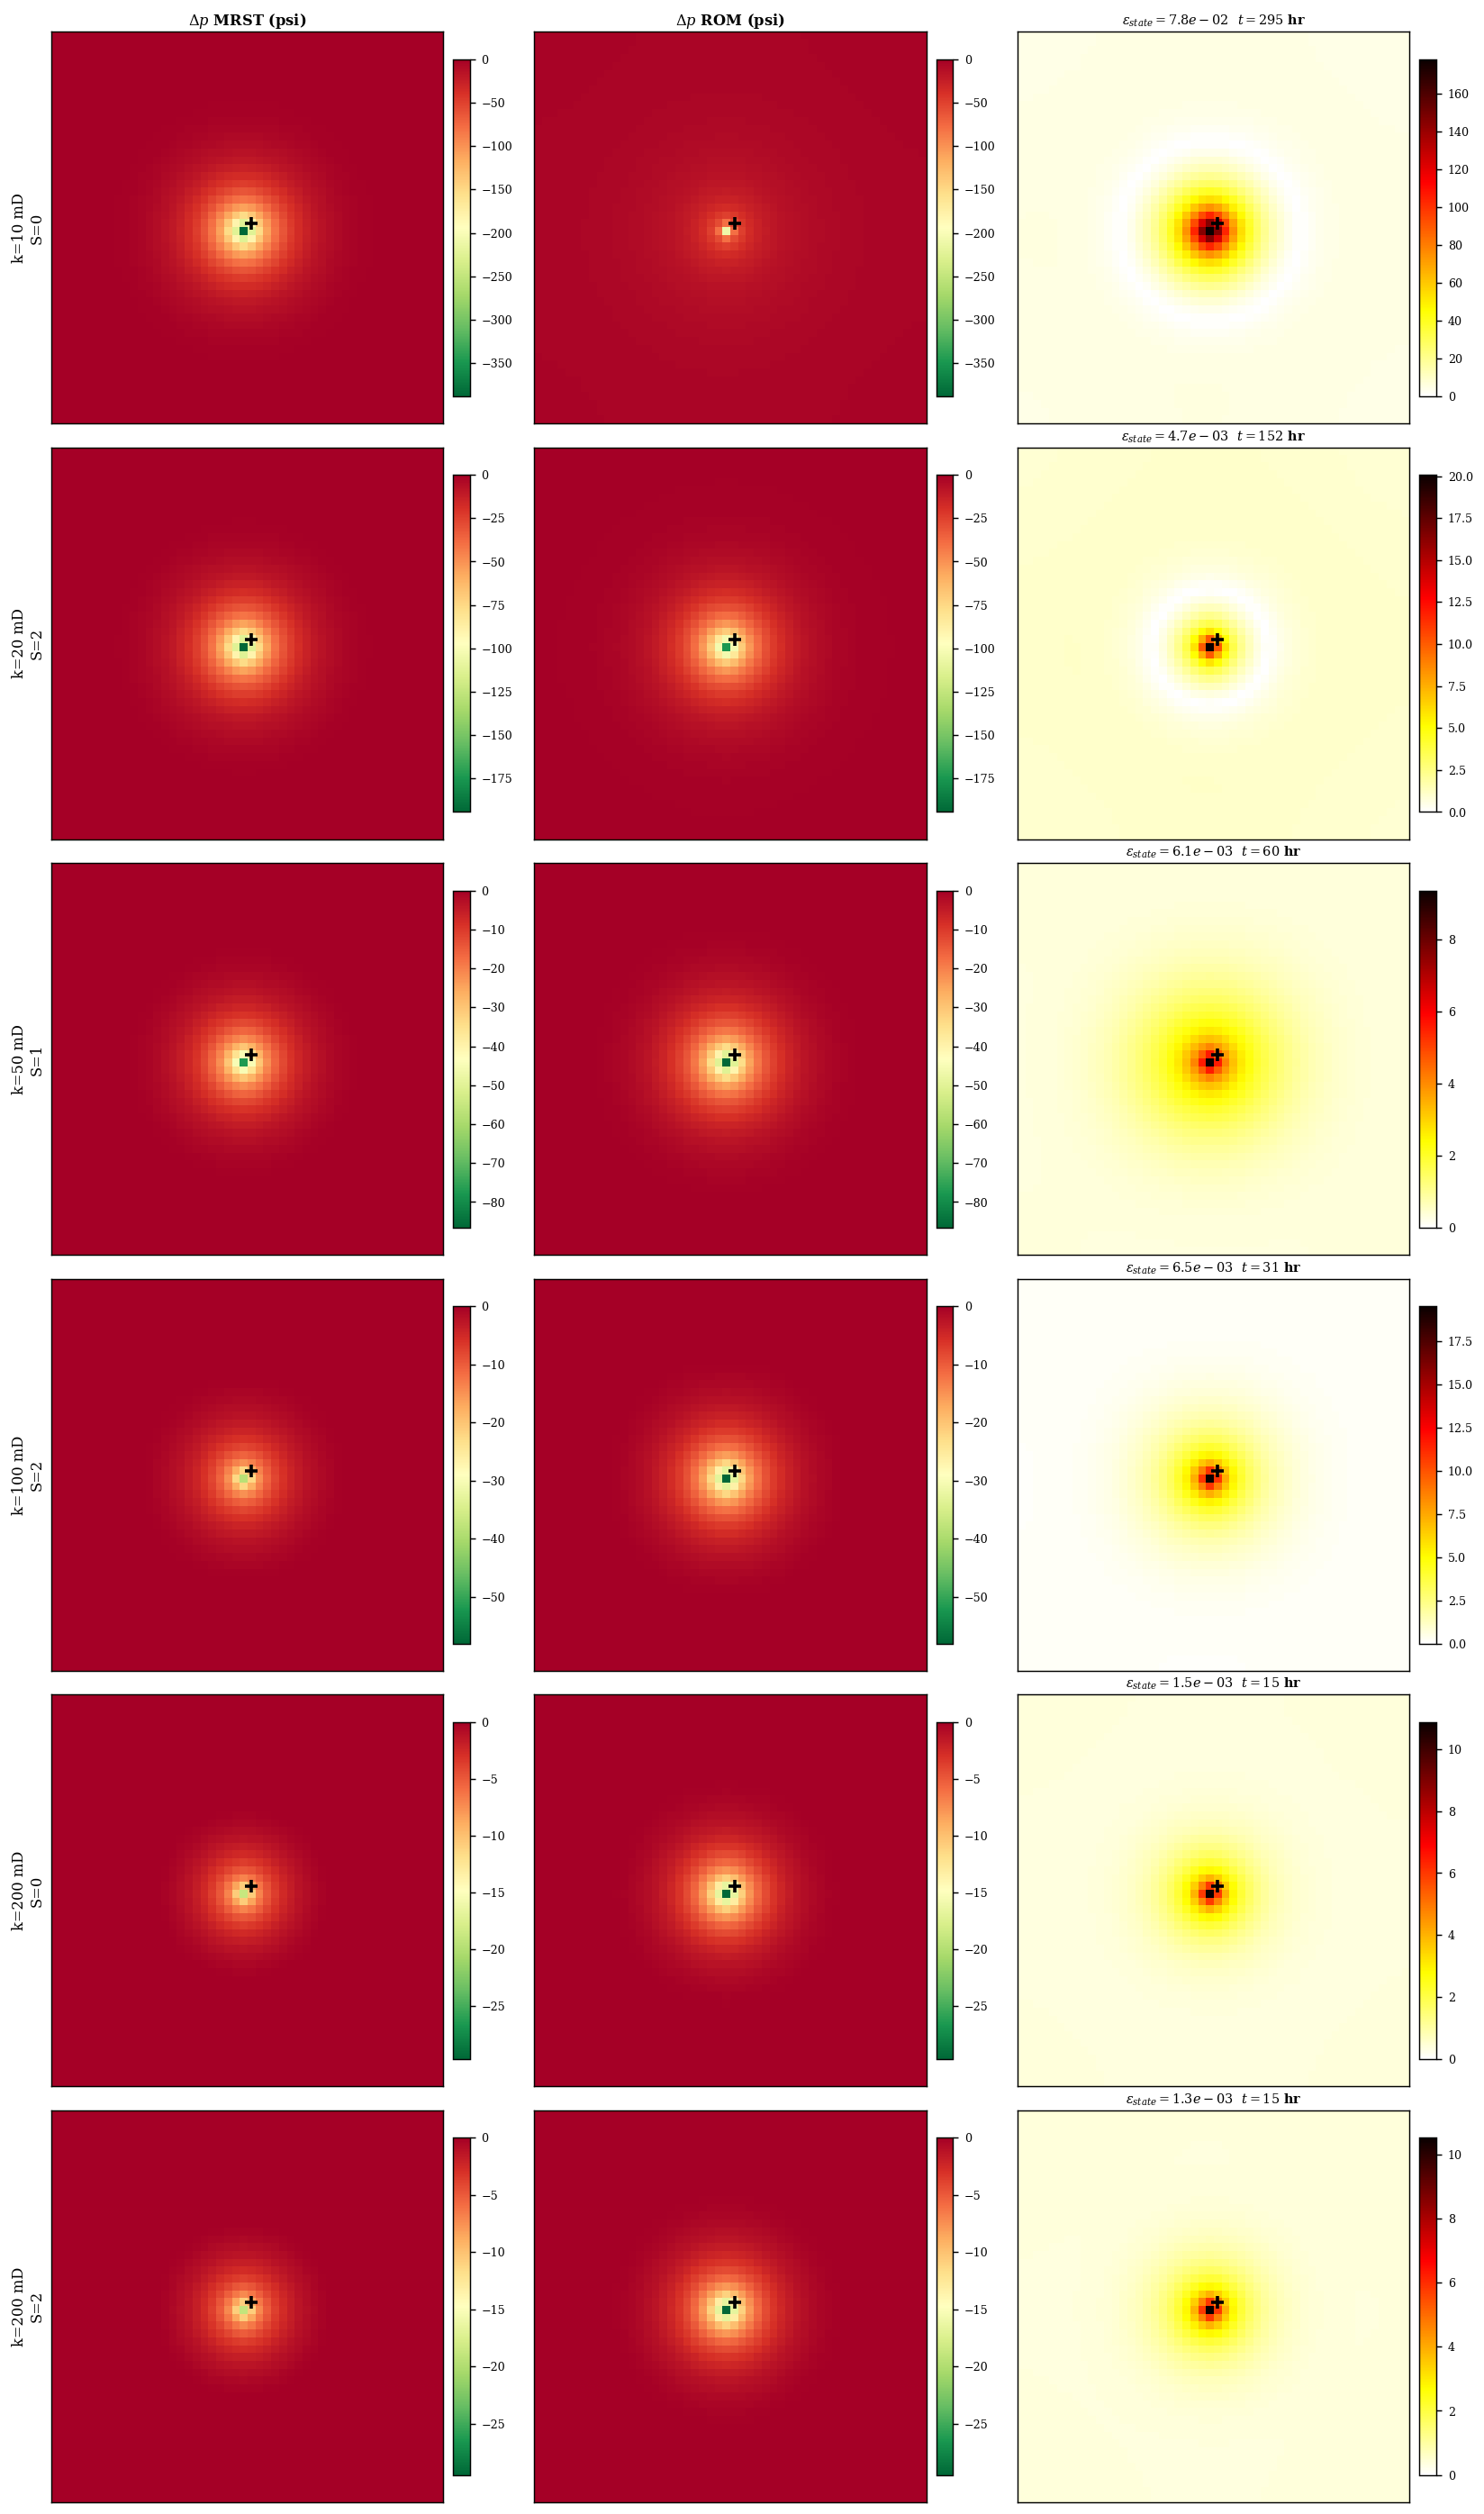

In [198]:
fig, axes = plt.subplots(NR, 3, figsize=(13, 3.6*NR))
for row, (k_v, s_v, sid) in enumerate(test_grid):
    cd   = TRAINING_DIR / f"k{k_v:03d}_s{s_v:02d}_sched{sid}"
    X_m  = load_mat(cd/"snapshots_psia.mat","X_psia")
    bhp_m, t_hr, q_v2, _, pm = load_well_data(cd)
    _, pf_r, _ = query_rom(k_v, s_v, t_hr, q_v2)
    t_pss = float(pm["t_pss_start_hr"])
    t_wbs = min(float(pm["t_wbs_end_hr"]), t_hr[-1])
    idx   = int(np.argmin(np.abs(t_hr - (t_wbs + t_pss)/2)))
    dp_m  = (X_m[:,idx] - P_INIT).reshape(NY,NX)
    dp_r  = (pf_r[:,idx] - P_INIT).reshape(NY,NX)
    err   = np.abs(dp_m - dp_r)
    vmax  = max(np.abs(dp_m).max(), np.abs(dp_r).max())
    se    = (np.linalg.norm(X_m-P_INIT-(pf_r-P_INIT),"fro")**2 /
             np.linalg.norm(X_m-P_INIT,"fro")**2)
    for col, (dat, cmap, vmin_, vmax_) in enumerate([
        (dp_m, "RdYlGn_r", -vmax, 0),
        (dp_r, "RdYlGn_r", -vmax, 0),
        (err,  "hot_r",    0,     err.max()),
    ]):
        ax = axes[row, col]
        im = ax.imshow(dat, origin="lower", cmap=cmap,
                       vmin=vmin_, vmax=vmax_, aspect="equal")
        ax.plot(NX//2, NY//2, "k+", ms=8, mew=2.0, zorder=10)
        ax.set_xticks([]); ax.set_yticks([])
        lbls = [r"$\Delta p$ MRST (psi)", r"$\Delta p$ ROM (psi)",
                r"$|\Delta p_\mathrm{err}|$ (psi)"]
        if row==0: ax.set_title(lbls[col], fontsize=9, pad=4)
        if col==0: ax.set_ylabel(f"k={k_v} mD\nS={s_v}", fontsize=9)
        if col==2: ax.set_title(f"$\\varepsilon_{{state}}={se:.1e}$  "
                                 f"$t={t_hr[idx]:.0f}$ hr", fontsize=8, pad=4)
        cb = plt.colorbar(im, ax=ax, shrink=0.86, pad=0.02)
        cb.ax.tick_params(labelsize=7)
plt.tight_layout(h_pad=0.3, w_pad=0.2)
plt.savefig(FIG_DIR/"fig09_pressure_fields.pdf", bbox_inches="tight")
plt.show()


## 6. ROM Prediction and Parametric Studies

The ROM evaluates any $(k^*,S^*)\in[10,300]\,\text{mD}\times[0,2]$
in $\mathcal{O}(n^3 N_t)$ time.

**Correctness criteria:**

- The Bourdet flat level $dp' = 70.6\,q\mu B_o/(kh) \propto 1/k$ (Study B).
- The flat level is independent of $S$ (Study C).


In [199]:
T_PRED = np.logspace(np.log10(T_START), np.log10(T_END), N_STEPS)

def schedule_qvec(sched, t_hr):
    q = np.full(len(t_hr), float(sched[0][1]))
    for tc, rv in sched[1:]:
        q[t_hr >= tc] = float(rv)
    return q

def predict(k_star, s_star, rate_sched):
    assert 10 <= k_star <= 300, f"k={k_star} outside [10,300] mD"
    assert  0 <= s_star <=  8,  f"S={s_star} outside [0,8]"
    q   = schedule_qvec(rate_sched, T_PRED)
    t0  = time.perf_counter()
    bhp, pf, stable = query_rom(k_star, s_star, T_PRED, q)
    return dict(t_hr=T_PRED, bhp_psia=bhp,
                dp_psi=np.clip(P_INIT-bhp, 0, None),
                p_field=pf, q_vec=q, stable=stable,
                wall_ms=(time.perf_counter()-t0)*1000)

print("predict() ready.  Valid range: k in [10, 300] mD,  S in {0, 8}")


predict() ready.  Valid range: k in [10, 300] mD,  S in {0, 8}


### 6.1 Study A — Multi-rate Schedule ($k=75$ mD, $S=1$)

k=75, S=1 | Wall: 10.0 ms | Stable: True
BHP: 4307.3 - 4428.1 psia
t_WBS = 0.33 hr


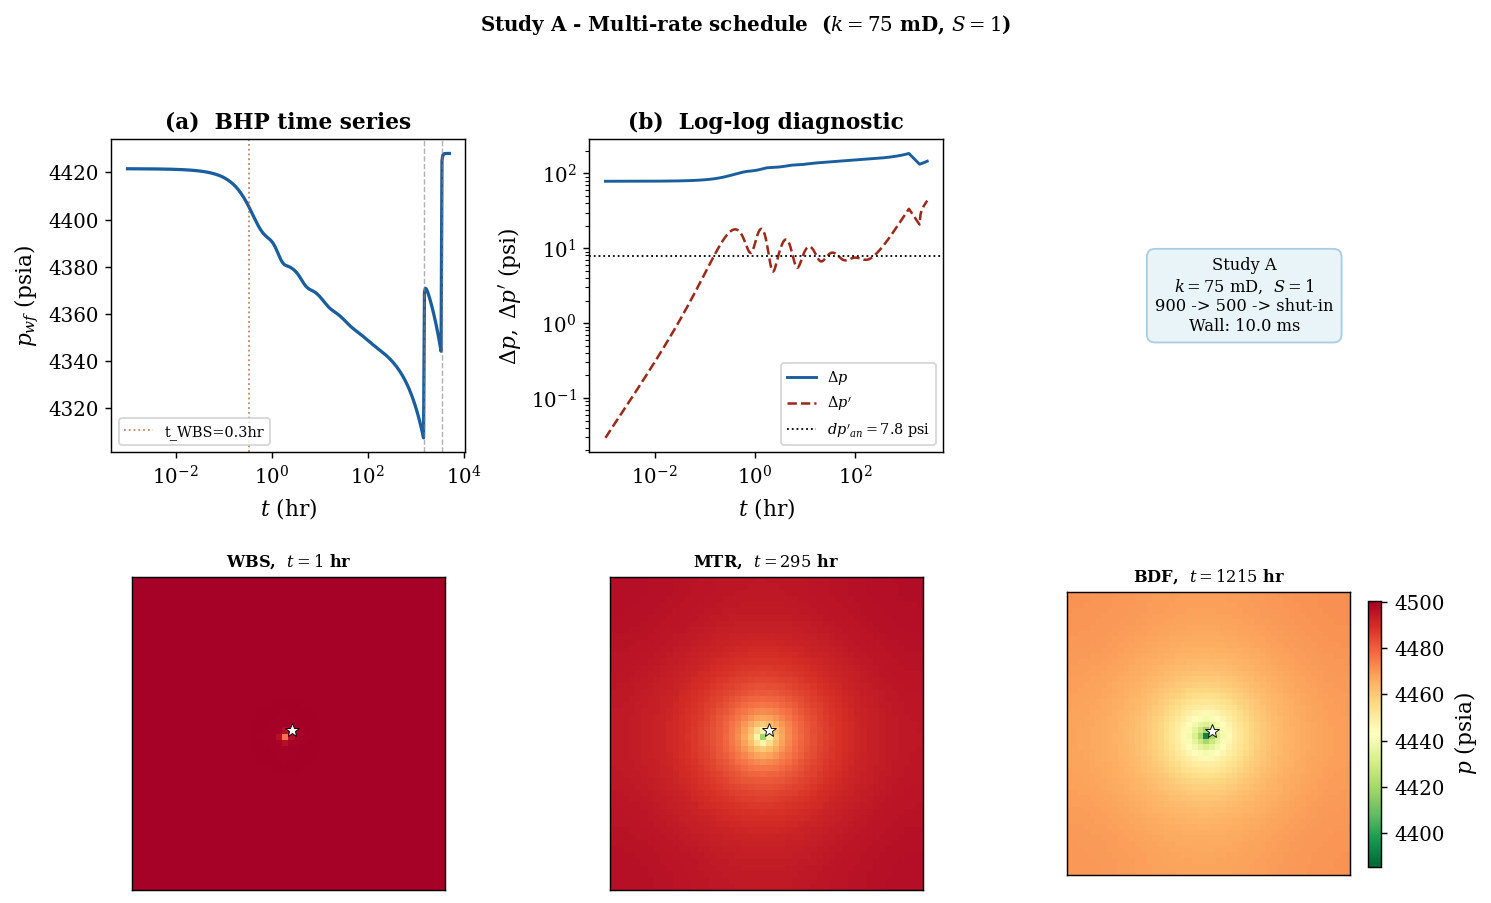

Figure saved.


In [208]:
rA = predict(75, 1, [(0, 900), (1500, 500), (3500, 0)])
t_wbs_A = 170000*C_WBS*np.exp(2*1)/(75*H_FT)
print(f"k=75, S=1 | Wall: {rA['wall_ms']:.1f} ms | Stable: {rA['stable']}")
print(f"BHP: {rA['bhp_psia'].min():.1f} - {rA['bhp_psia'].max():.1f} psia")
print(f"t_WBS = {t_wbs_A:.2f} hr")

dpA  = np.clip(rA["dp_psi"], 1e-2, None)
tA, dpA_b, bdA = bourdet(rA["t_hr"], dpA)
dp_an_A = 70.6*900*MU_CP*BO/(75*H_FT)

fig = plt.figure(figsize=(13, 7.5))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0,0])
ax1.semilogx(rA["t_hr"], rA["bhp_psia"], color=C1, lw=1.8)
for tc, _ in [(1500,None),(3500,None)]:
    ax1.axvline(tc, color="gray", ls="--", lw=0.8, alpha=0.6)
ax1.axvline(t_wbs_A, color="sienna", ls=":", lw=1.0, alpha=0.7, label=f"t_WBS={t_wbs_A:.1f}hr")
ax1.set_xlabel("$t$ (hr)"); ax1.set_ylabel("$p_{wf}$ (psia)")
ax1.set_title("(a)  BHP time series"); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0,1])
if len(bdA)>2:
    ax2.loglog(tA, dpA_b, color=C1, lw=1.6, label=r"$\Delta p$")
    ax2.loglog(tA, bdA,   color=C3, lw=1.4, ls="--", label=r"$\Delta p'$")
ax2.axhline(dp_an_A, color="k", ls=":", lw=1, label=f"$dp'_{{an}}={dp_an_A:.1f}$ psi")
ax2.set_xlabel("$t$ (hr)"); ax2.set_ylabel(r"$\Delta p,\;\Delta p'$ (psi)")
ax2.set_title("(b)  Log-log diagnostic"); ax2.legend(fontsize=8)

snaps = [("WBS",np.argmin(np.abs(rA["t_hr"]-0.5))),
         ("MTR",np.argmin(np.abs(rA["t_hr"]-300))),
         ("BDF",np.argmin(np.abs(rA["t_hr"]-1200)))]
pm_pf = rA["p_field"].min(); px_pf = rA["p_field"].max()
for col,(lbl,idx) in enumerate(snaps):
    ax = fig.add_subplot(gs[1,col])
    im  = ax.imshow(rA["p_field"][:,idx].reshape(NY,NX),
                    origin="lower",cmap="RdYlGn_r",vmin=pm_pf,vmax=px_pf,aspect="equal")
    ax.plot(NX//2,NY//2,"w*",ms=8,mec="k",mew=0.5,zorder=5)
    ax.set_title(f"{lbl},  $t={rA['t_hr'][idx]:.0f}$ hr", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if col==2: plt.colorbar(im,ax=ax,shrink=0.85,label="$p$ (psia)")

ax_i = fig.add_subplot(gs[0,2]); ax_i.axis("off")
ax_i.text(0.5,0.5,
    f"Study A\n$k=75$ mD,  $S=1$\n900 -> 500 -> shut-in\nWall: {rA['wall_ms']:.1f} ms",
    ha="center",va="center",fontsize=9,
    bbox=dict(boxstyle="round,pad=0.5",fc="#e8f4f8",ec="#aacce0"))
fig.suptitle("Study A - Multi-rate schedule  ($k=75$ mD, $S=1$)",
             fontsize=11,fontweight="bold",y=1.01)
plt.savefig(FIG_DIR/"fig10_studyA.png",dpi=150,bbox_inches="tight")
plt.show(); print("Figure saved.")


### 6.2 Study B — Permeability Sweep ($S=1$, $q=800$ STB/d)

Total wall time: 37 ms


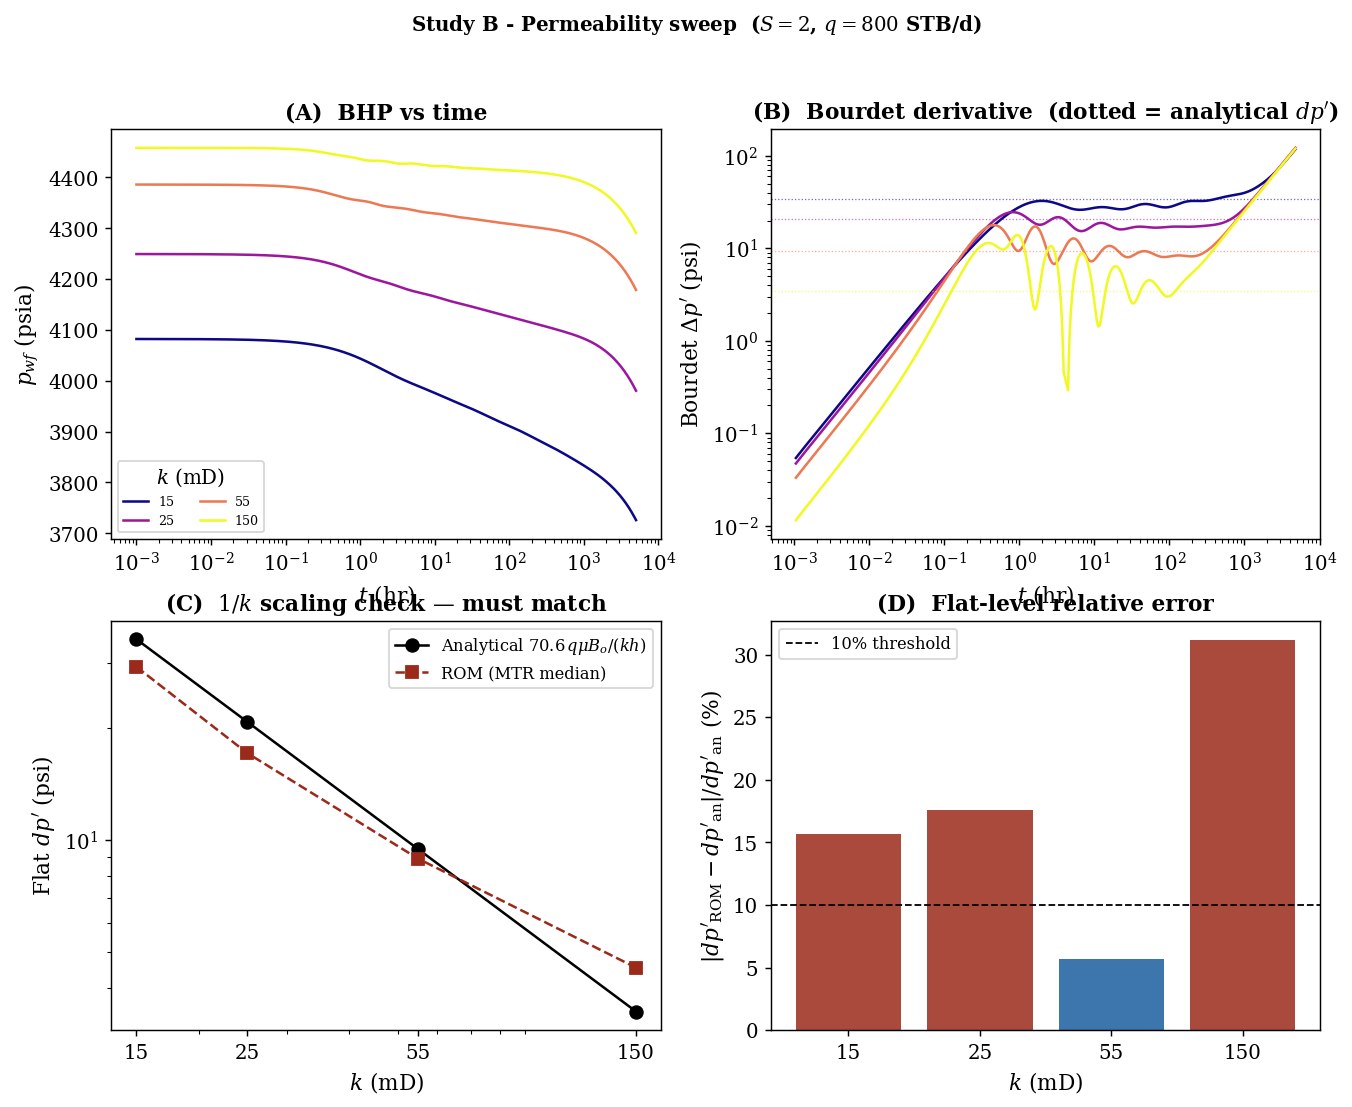

Figure saved.


In [214]:
k_sweep = [15, 25, 55, 150]
S_fixed = 2
cmap_b  = plt.cm.plasma
cols_b  = [cmap_b(i/(len(k_sweep)-1)) for i in range(len(k_sweep))]
res_B   = {k: predict(k, S_fixed, [(0,800)]) for k in k_sweep}
print(f"Total wall time: {sum(r['wall_ms'] for r in res_B.values()):.0f} ms")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for k_v, col in zip(k_sweep, cols_b):
    r = res_B[k_v]
    axes[0,0].semilogx(r["t_hr"], r["bhp_psia"], color=col, lw=1.4, label=f"{k_v}")
axes[0,0].set_xlabel("$t$ (hr)"); axes[0,0].set_ylabel("$p_{wf}$ (psia)")
axes[0,0].set_title("(A)  BHP vs time")
axes[0,0].legend(title="$k$ (mD)", fontsize=7, ncol=2)

flat_sim = []; flat_an = []
for k_v, col in zip(k_sweep, cols_b):
    r   = res_B[k_v]
    dp  = np.clip(r["dp_psi"], 0.1, None)
    t_,d_,bd = bourdet(r["t_hr"], dp)
    if len(bd)>3: axes[0,1].loglog(t_, bd, color=col, lw=1.4)
    dp_an = 70.6*800*MU_CP*BO/(k_v*H_FT)
    axes[0,1].axhline(dp_an, color=col, ls=":", lw=0.7, alpha=0.6)
    t_pss = (PHI*MU_CP*CT*RE_FT**2)/(0.000264*k_v)*0.1
    t_wbs_k = 170000*C_WBS*np.exp(2*S_fixed)/(k_v*H_FT)
    mtr_m = (t_ >= t_wbs_k) & (t_ <= t_pss)
    flat_sim.append(float(np.median(bd[mtr_m])) if mtr_m.sum()>3 else np.nan)
    flat_an.append(dp_an)
axes[0,1].set_xlabel("$t$ (hr)"); axes[0,1].set_ylabel(r"Bourdet $\Delta p'$ (psi)")
axes[0,1].set_title(r"(B)  Bourdet derivative  (dotted = analytical $dp'$)")

axes[1,0].loglog(k_sweep, flat_an, "k-o", lw=1.4, ms=7,
                 label=r"Analytical $70.6\,q\mu B_o/(kh)$")
axes[1,0].loglog(k_sweep, flat_sim, "s--", color=C3, lw=1.4, ms=7,
                 label="ROM (MTR median)")
axes[1,0].set_xlabel("$k$ (mD)"); axes[1,0].set_ylabel(r"Flat $dp'$ (psi)")
axes[1,0].set_title(r"(C)  $1/k$ scaling check — must match")
axes[1,0].legend(fontsize=9)
axes[1,0].set_xticks(k_sweep); axes[1,0].set_xticklabels(k_sweep)

rel_err = [abs(s-a)/a*100 if not np.isnan(s) else np.nan
           for s,a in zip(flat_sim,flat_an)]
axes[1,1].bar(range(len(k_sweep)), rel_err,
              color=[C1 if e<10 else C3 for e in rel_err], alpha=0.85)
axes[1,1].axhline(10, color="k", ls="--", lw=1, label="10% threshold")
axes[1,1].set_xticks(range(len(k_sweep))); axes[1,1].set_xticklabels(k_sweep)
axes[1,1].set_xlabel("$k$ (mD)"); axes[1,1].set_ylabel(r"$|dp'_\mathrm{ROM} - dp'_\mathrm{an}| / dp'_\mathrm{an}$ (%)")
axes[1,1].set_title("(D)  Flat-level relative error"); axes[1,1].legend(fontsize=9)

fig.suptitle(f"Study B - Permeability sweep  ($S={S_fixed}$, $q=800$ STB/d)",
             fontsize=11, fontweight="bold")
plt.savefig(FIG_DIR/"fig11_studyB.png", dpi=150, bbox_inches="tight")
plt.show(); print("Figure saved.")


### 6.3 Study C — Skin Sweep ($k=50$ mD, $q=800$ STB/d)

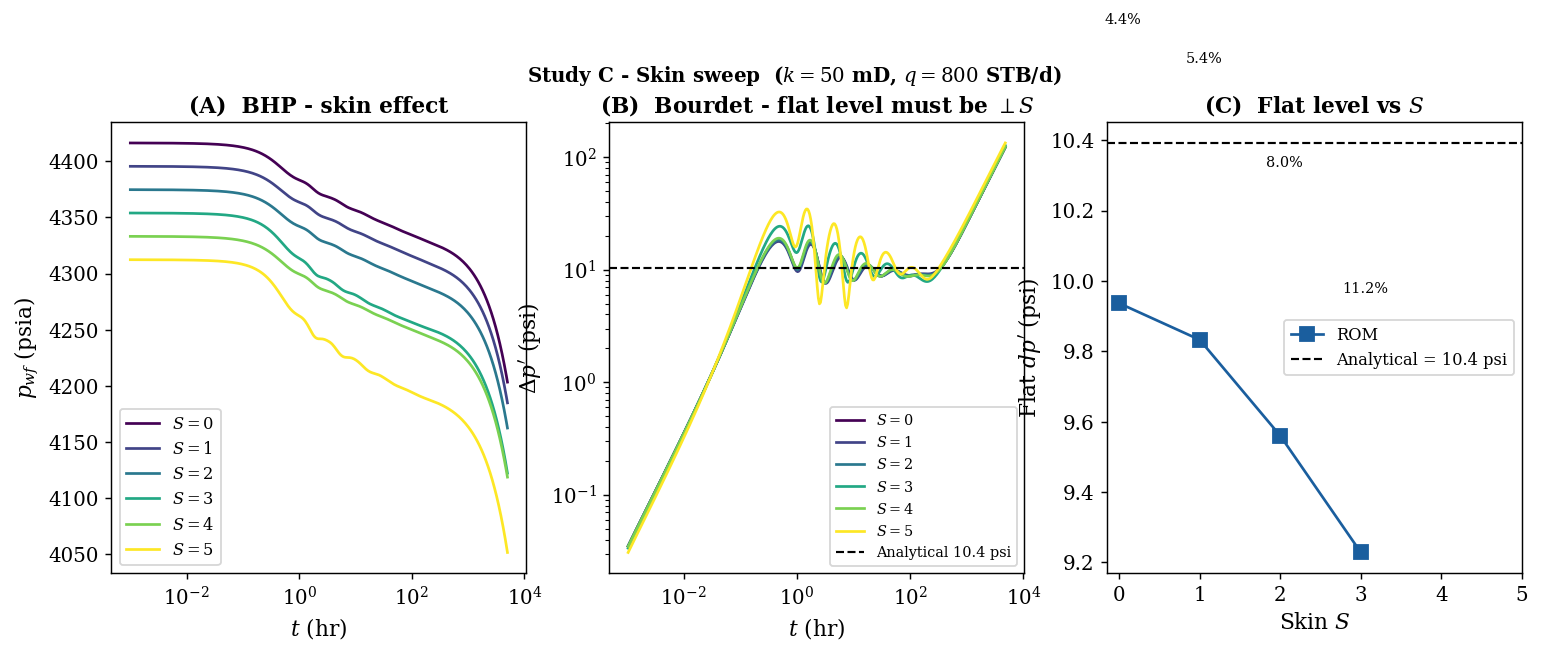

Figure saved.


In [212]:
S_sweep = [0, 1, 2, 3, 4, 5]
k_fixed = 50
cmap_c  = plt.cm.viridis
cols_c  = [cmap_c(i/(len(S_sweep)-1)) for i in range(len(S_sweep))]
res_C   = {s: predict(k_fixed, s, [(0,800)]) for s in S_sweep}
dp_an_k50 = 70.6*800*MU_CP*BO/(k_fixed*H_FT)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for s_v, col in zip(S_sweep, cols_c):
    r = res_C[s_v]
    axes[0].semilogx(r["t_hr"], r["bhp_psia"], color=col, lw=1.5, label=f"$S={s_v}$")
axes[0].set_xlabel("$t$ (hr)"); axes[0].set_ylabel("$p_{wf}$ (psia)")
axes[0].set_title("(A)  BHP - skin effect"); axes[0].legend(fontsize=9)

flat_s = []
for s_v, col in zip(S_sweep, cols_c):
    r  = res_C[s_v]
    dp = np.clip(r["dp_psi"], 0.1, None)
    t_,d_,bd = bourdet(r["t_hr"], dp)
    if len(bd)>3: axes[1].loglog(t_, bd, color=col, lw=1.5, label=f"$S={s_v}$")
    t_pss   = (PHI*MU_CP*CT*RE_FT**2)/(0.000264*k_fixed)*0.1
    t_wbs_s = 170000*C_WBS*np.exp(2*s_v)/(k_fixed*H_FT)
    mtr_m   = (t_ >= t_wbs_s) & (t_ <= t_pss)
    flat_s.append(float(np.median(bd[mtr_m])) if mtr_m.sum()>3 else np.nan)
axes[1].axhline(dp_an_k50, color="k", ls="--", lw=1.2,
                label=f"Analytical {dp_an_k50:.1f} psi")
axes[1].set_xlabel("$t$ (hr)"); axes[1].set_ylabel(r"$\Delta p'$ (psi)")
axes[1].set_title(r"(B)  Bourdet - flat level must be $\perp S$")
axes[1].legend(fontsize=8)

axes[2].plot(S_sweep, flat_s, "s-", color=C1, ms=8, lw=1.5, label="ROM")
axes[2].axhline(dp_an_k50, color="k", ls="--", lw=1.2,
                label=f"Analytical = {dp_an_k50:.1f} psi")
for s_v, fs in zip(S_sweep, flat_s):
    if not np.isnan(fs):
        axes[2].annotate(f"{abs(fs-dp_an_k50)/dp_an_k50*100:.1f}%",
                         xy=(s_v, fs), xytext=(s_v+0.05, fs*1.08),
                         fontsize=8, ha="center")
axes[2].set_xlabel("Skin $S$"); axes[2].set_ylabel(r"Flat $dp'$ (psi)")
axes[2].set_title("(C)  Flat level vs $S$"); axes[2].legend(fontsize=9)
axes[2].set_xticks(S_sweep)

fig.suptitle(f"Study C - Skin sweep  ($k={k_fixed}$ mD, $q=800$ STB/d)",
             fontsize=11, fontweight="bold")
plt.savefig(FIG_DIR/"fig12_studyC.png", dpi=150, bbox_inches="tight")
plt.show(); print("Figure saved.")


## 7. Summary

In [203]:
t0_rom = time.perf_counter()
for _ in range(20):
    query_rom(50, 1, T_PRED, np.full(N_STEPS, 800.0))
rom_ms = (time.perf_counter()-t0_rom)/20*1000

print("=" * 62)
print(" REDUCED ORDER MODEL - FINAL SUMMARY")
print("=" * 62)
print(f"  FOM                 : MRST {NX}x{NY} = {N_CELLS} cells")
print(f"  Training pairs      : {len(VALID_PAIRS)}/36 (after physics screening)")
print(f"  Excluded pairs      : {36-len(VALID_PAIRS)}/36 (no MTR data)")
print(f"  Valid parameter space: k in [10,300] mD,  S in {{0,1,2}}")
print(f"  POD modes (n)       : {N_MODES}")
print(f"  Proj error (max)    : {np.max(per_err):.2e}")
print(f"  LOO interp error    : mean={loo_errors.mean():.2e}  max={loo_errors.max():.2e}")
print(f"  Validation state err: {t2_df['state_err'].mean():.2e} (mean)")
print(f"  Validation output err: {t2_df['out_err'].mean():.2e} (mean)")
print(f"  ROM wall time/query : {rom_ms:.1f} ms")
print(f"  MRST wall time      : ~180000 ms  (~3 min)")
print(f"  Speedup             : ~{180000/rom_ms:.0f} x")
print("=" * 62)
print()
print(f"Figures : {FIG_DIR.resolve()}")
print(f"ROM     : {ROM_DIR.resolve()}")
t2_df.to_csv(ROM_DIR/"results"/"validation_errors.csv", index=False)
print("Validation errors saved.")


 REDUCED ORDER MODEL - FINAL SUMMARY
  FOM                 : MRST 50x50 = 2500 cells
  Training pairs      : 36/36 (after physics screening)
  Excluded pairs      : 0/36 (no MTR data)
  Valid parameter space: k in [10,300] mD,  S in {0,1,2}
  POD modes (n)       : 15
  Proj error (max)    : 3.16e-11
  LOO interp error    : mean=4.05e+00  max=2.54e+01
  Validation state err: 1.63e-02 (mean)
  Validation output err: 3.01e-02 (mean)
  ROM wall time/query : 14.7 ms
  MRST wall time      : ~180000 ms  (~3 min)
  Speedup             : ~12230 x

Figures : F:\Niloy Deb\Part Two\reservoir_rom\figures
ROM     : F:\Niloy Deb\Part Two\reservoir_rom\rom
Validation errors saved.
